In [264]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

import config
import pipeline
importlib.reload(config)
importlib.reload(pipeline)

# ── Display active parameters ─────────────────────────────────────────────────
# Edit config.py to change any of these — no changes to this notebook needed.
print("=" * 55)
print("TARIFF PCE PIPELINE — ACTIVE CONFIGURATION")
print("=" * 55)
rows = [
    ("BEA IO year",             config.IO_YEAR),
    ("Leontief source",         config.LEONTIEF_SOURCE),
    ("Tariff baseline year",    config.TARIFF_BASELINE_YEAR),
    ("Tariff current month",    config.TARIFF_CURRENT_MONTH),
    ("Markup assumption",       config.MARKUP_ASSUMPTION),
    ("Inflation measure",       config.INFLATION_MEASURE),
    ("Counterfactual baseline", config.COUNTERFACTUAL_BASELINE_MONTH),
    ("Excess inflation window", f"{config.EXCESS_BASELINE_START}–{config.EXCESS_BASELINE_END}"),
    ("Excess current window",   f"{config.EXCESS_CURRENT_START_MONTH} → {config.EXCESS_CURRENT_END_MONTH}"),
    ("Real PCE growth window",  f"{config.REAL_PCE_GROWTH_START_MONTH} → {config.REAL_PCE_GROWTH_END_MONTH}"),
    ("Core goods categories",   len(config.CORE_GOODS_CATEGORIES)),
]
for label, val in rows:
    print(f"  {label:<30} {val}")
print("=" * 55)


TARIFF PCE PIPELINE — ACTIVE CONFIGURATION
  BEA IO year                    2022
  Leontief source                computed
  Tariff baseline year           2024
  Tariff current month           2025-12
  Markup assumption              constant_dollar
  Inflation measure              core_pce
  Counterfactual baseline        2024-12
  Excess inflation window        2024–2024
  Excess current window          2024-12 → 2025-12
  Real PCE growth window         2023-12 → 2024-12
  Core goods categories          27


In [265]:
# ── Step 1: Direct import shares (m_i = imports / total supply) ──────────────
# Methodology §2 / BEA Supply Table 262

import_shares = pipeline.step1_import_shares(config.IO_YEAR, config.BEA_KEY)

print(f"Commodities: {len(import_shares)}")
print(f"Import share range: "
      f"{import_shares['import_share'].min():.4f} – {import_shares['import_share'].max():.4f}")
print(f"\nTop 10 by direct import share:")
print(
    import_shares.nlargest(10, 'import_share')
    [['BEA_code', 'BEA_descr', 'import_share']]
    .to_string(index=False)
)


Commodities: 54
Import share range: 0.0000 – 0.9817

Top 10 by direct import share:
BEA_code                                              BEA_descr  import_share
   Other Noncomparable imports and rest-of-the-world adjustment           1.0
   315AL                Apparel and leather and allied products           0.9
    Used                       Scrap, used and secondhand goods           0.6
     334                       Computer and electronic products           0.6
     335       Electrical equipment, appliances, and components           0.5
     339                            Miscellaneous manufacturing           0.5
   313TT                Textile mills and textile product mills           0.5
     337                         Furniture and related products           0.4
     333                                              Machinery           0.3
  3361MV         Motor vehicles, bodies and trailers, and parts           0.3


In [266]:
# ── Steps 2–3: Technical coefficients (A) and Leontief inverse (L) ───────────
# Methodology §3–4 / BEA Use Table 259
# config.LEONTIEF_SOURCE: "computed" (default) or "bea" (BEA TableID 59)

industries, A, L = pipeline.step2_3_leontief(
    config.IO_YEAR, config.BEA_KEY, config.LEONTIEF_SOURCE
)

I_n = np.eye(len(industries))
print(f"Industries: {len(industries)}")
print(f"A matrix shape:                  {A.shape}")
print(f"Max A column sum (must be < 1):  {A.sum(axis=0).max():.4f}")
print(f"Condition number of (I - A):     {np.linalg.cond(I_n - A):.1f}")
print(f"Leontief diagonal mean (> 1):    {np.diag(L).mean():.4f}")
print(f"L min value (should be ≥ 0):     {L.min():.4f}")


Leontief source: computed from (I - A)^{-1} via Use Table 259
Industries: 68
A matrix shape:                  (68, 68)
Max A column sum (must be < 1):  0.9079
Condition number of (I - A):     3.2
Leontief diagonal mean (> 1):    1.1124
L min value (should be ≥ 0):     0.0000


In [267]:
# ── Validation: compare computed L against BEA pre-computed Total Requirements ─
# BEA TableID 59 = Commodity-by-Commodity Total Requirements, Summary (= Leontief inverse)
# Differences should be very small (< 0.001), reflecting only BEA's internal
# rounding when publishing the pre-computed table.

val = pipeline.validate_leontief(config.IO_YEAR, config.BEA_KEY, industries, L)

print(f"Max absolute difference:  {val['max_abs_diff']:.6f}")
print(f"Mean absolute difference: {val['mean_abs_diff']:.6f}")
print(f"Max relative difference:  {val['max_rel_diff']:.4%}")
print(f"\nTop 10 largest element-wise differences:")
print(val["top_diffs"].to_string(index=False))


Max absolute difference:  0.219883
Mean absolute difference: 0.003983
Max relative difference:  1468.4211%

Top 10 largest element-wise differences:
row_industry col_industry  L_computed  L_bea  abs_diff
          42       3361MV         0.0    0.2       0.2
       111CA        311FT         0.6    0.4       0.2
          42        311FT         0.0    0.2       0.2
          42          331         0.0    0.2       0.2
          42          321         0.0    0.2       0.2
          42          333         0.0    0.2       0.2
          42        111CA         0.0    0.2       0.1
          42          335         0.0    0.2       0.1
          42          337         0.0    0.1       0.1
          42          322         0.0    0.1       0.1


In [268]:
# ── Step 4: Total import content (m_total = m' L) ────────────────────────────
# Methodology §5
# Supply-chain amplification: how much indirect imports add on top of direct shares.

m_vec, m_total = pipeline.step4_total_import_content(import_shares, industries, L)

print(f"Direct import shares mean:   {m_vec.mean():.4f}")
print(f"Total import content mean:   {m_total.mean():.4f}")
print(f"Supply-chain amplification:  {m_total.mean() / m_vec.mean():.2f}×")
print(f"\nSample — direct vs. total import content (first 15 industries):")
print(f"  {'Industry':<14}  {'Direct':>8}  {'Total':>8}  {'Ratio':>6}")
for i, ind in enumerate(industries[:15]):
    ratio = m_total[i] / m_vec[i] if m_vec[i] > 0 else float('nan')
    print(f"  {ind:<14}  {m_vec[i]:8.4f}  {m_total[i]:8.4f}  {ratio:6.2f}×")


Direct import shares mean:   0.1026
Total import content mean:   0.2232
Supply-chain amplification:  2.18×

Sample — direct vs. total import content (first 15 industries):
  Industry          Direct     Total   Ratio
  111CA             0.0907    0.2643    2.91×
  113FF             0.2433    0.3368    1.38×
  211               0.2901    0.4381    1.51×
  212               0.0628    0.1808    2.88×
  213               0.0107    0.0951    8.86×
  22                0.0055    0.0902   16.44×
  23                0.0000    0.1956     nan×
  311FT             0.1094    0.3332    3.04×
  313TT             0.4577    0.7946    1.74×
  315AL             0.8963    1.0369    1.16×
  321               0.1721    0.4112    2.39×
  322               0.1307    0.3563    2.73×
  323               0.0423    0.2223    5.26×
  324               0.0957    0.4031    4.21×
  325               0.2899    0.4692    1.62×


In [269]:
# ── Step 5: Δτ = τ_current − τ_baseline per BEA industry ─────────────────────
# Methodology §6
# Baseline: annual average over all 12 months of config.TARIFF_BASELINE_YEAR
# Current:  single month config.TARIFF_CURRENT_MONTH

delta_tariff_df = pipeline.step5_delta_tariff(
    config.IMPORTS_FILE,
    config.TARIFF_BASELINE_YEAR,
    config.TARIFF_CURRENT_MONTH,
)

print(f"BEA industries: {len(delta_tariff_df)}")
print(f"\nTop 10 by tariff increase (Δτ):")
print(
    delta_tariff_df.nlargest(10, 'delta_tariff')
    [['bea_io', 'bea_desc', 'tau_base', 'tau', 'delta_tariff']]
    .to_string(index=False)
)


Concordance built: 384/388 NAICS6 codes mapped to BEA IO industries
  Out of scope (services/unmapped): 4 codes
  BEA IO industries covered: 22

Import value coverage: 95.3% of total import value mapped to BEA IO industries

BEA IO industries with no tariff data (tau set to 0):
bea_io                      bea_desc
   213 Support activities for mining

Import value coverage: 94.2% of total import value mapped to BEA IO industries

BEA IO industries with no tariff data (tau set to 0):
bea_io                      bea_desc
   213 Support activities for mining
BEA industries: 24

Top 10 by tariff increase (Δτ):
bea_io                                         bea_desc  tau_base  tau  delta_tariff
   332                        Fabricated metal products       0.1  0.3           0.2
 313TT          Textile mills and textile product mills       0.1  0.3           0.2
   337                   Furniture and related products       0.1  0.2           0.2
 315AL          Apparel and leather and allied

In [270]:
# ── PCE Bridge + Step 6: Predicted tariff effect per PCE category ─────────────
# Methodology §7
# Markup assumption (config.MARKUP_ASSUMPTION):
#   "constant_dollar"  → numerator weighted by producers' value (Fed conservative baseline)
#   "constant_percent" → numerator weighted by purchasers' value (larger consumer effect)

pce_bridge    = pipeline.load_pce_bridge(config.IO_YEAR, config.BEA_KEY)
pce_effect_df = pipeline.step6_pce_effect(
    industries      = industries,
    m_vec           = m_vec,
    L               = L,
    delta_tariff_df = delta_tariff_df,
    pce_bridge      = pce_bridge,
    markup          = config.MARKUP_ASSUMPTION,
)

print(f"Markup assumption: {config.MARKUP_ASSUMPTION}")
print(f"\nTop 15 PCE categories by predicted tariff effect:")
print(pce_effect_df.head(15)[['PCE_category', 'predicted_effect']].to_string(index=False))

# Weighted-average effect on core goods — carried forward to counterfactual cells
core = pce_effect_df.query('PCE_category in @config.CORE_GOODS_CATEGORIES')
core_effect = (
    (core['predicted_effect'] * core['purchasers_value_total']).sum()
    / core['purchasers_value_total'].sum()
)
print(f"\nWeighted avg predicted effect — core goods: {core_effect:.2%}")


Markup assumption: constant_dollar

Top 15 PCE categories by predicted tariff effect:
                                      PCE_category  predicted_effect
                          Men's and boys' clothing               0.1
                Luggage and similar personal items               0.1
             Other clothing materials and footwear               0.1
                       Women's and girls' clothing               0.1
                                New motor vehicles               0.0
                              Household appliances               0.0
                               Musical instruments               0.0
                         Furniture and furnishings               0.0
      Glassware, tableware, and household utensils               0.0
                  Sports and recreational vehicles               0.0
                  Children's and infants' clothing               0.0
Sporting equipment, supplies, guns, and ammunition               0.0
               Mo

In [271]:
# ── Worked example: trace full methodology chain for a single industry ────────
# Call pipeline.trace_industry() with any BEA IO code to see every step:
#   Step 1  — direct import share
#   Step 4  — total import content via Leontief (supply-chain amplification)
#   Step 5  — tariff change (Δτ) and predicted producer-level price effect
#   Step 6  — PCE bridge breakdown and final consumer-price effect
#
# All inputs come from the cells above — no recomputation needed.
# Change BEA_CODE to trace any industry (e.g. '3364OT', '3360OP', '3330SS').

BEA_CODE = "3361MV"   # Motor vehicles, bodies and trailers, and parts

pipeline.trace_industry(
    bea_code        = BEA_CODE,
    import_shares   = import_shares,
    industries      = industries,
    L               = L,
    m_vec           = m_vec,
    m_total         = m_total,
    delta_tariff_df = delta_tariff_df,
    pce_bridge      = pce_bridge,
    pce_effect_df   = pce_effect_df,
    markup          = config.MARKUP_ASSUMPTION,
)

────────────────────────────────────────────────────────────────
  INDUSTRY TRACE  ·  3361MV  —  Motor vehicles, bodies and trailers, and parts
────────────────────────────────────────────────────────────────

Step 1  —  Direct import share  (m_i = imports / total supply)
  imports       =       353,470  ($M)
  total supply  =     1,044,509  ($M)
  m_i           =         33.8%

Step 4  —  Total import content via Leontief  (m̃_j = m′ L)
  direct m_i     =         33.8%  (imports at the border)
  total m̃_j      =         80.4%  (direct + all upstream tiers)
  indirect share =         46.6%  (embedded in domestic inputs)
  amplification  =          2.38×

Step 5  —  Import tariff change  (Δτ = τ_current − τ_baseline)
  τ_baseline  =          1.9%
  τ_current   =         14.4%
  Δτ          =        +12.5%

Step 5  —  Predicted producer-level price effect  (p̂_j = Σ_i m_i·Δτ_i·L_ij)
  p̂_j             =          9.3%
  Naive approx    =         10.0%  (m̃_j × Δτ_j, ignores upstream tari

In [272]:
# ── Step 7a: Monthly counterfactual (NIPA T20804) ────────────────────────────
# Methodology §8
# config.INFLATION_MEASURE: "core_pce" (PCE ex food & energy) or "headline_pce"
# For the core-goods quarterly index, see Cell 8.

if config.INFLATION_MEASURE == "core_goods_pce":
    print("INFLATION_MEASURE = 'core_goods_pce' — skipping monthly counterfactual.")
    print("The quarterly core-goods counterfactual is computed in Cell 8.")
else:
    baseline_yr = int(config.COUNTERFACTUAL_BASELINE_MONTH[:4])
    current_yr  = int(config.TARIFF_CURRENT_MONTH[:4])
    years       = sorted({baseline_yr, current_yr})

    inflation_series = pipeline.step7_load_inflation(
        config.INFLATION_MEASURE, config.BEA_KEY, years
    )
    result = pipeline.step7_counterfactual(
        inflation_series      = inflation_series,
        pce_effect_df         = pce_effect_df,
        baseline_month        = config.COUNTERFACTUAL_BASELINE_MONTH,
        current_month         = config.TARIFF_CURRENT_MONTH,
        core_goods_categories = config.CORE_GOODS_CATEGORIES,
    )

    label = "Core PCE" if config.INFLATION_MEASURE == "core_pce" else "Headline PCE"
    print(f"{label}  ({config.COUNTERFACTUAL_BASELINE_MONTH} → {config.TARIFF_CURRENT_MONTH})")
    print(f"  Actual inflation:            {result['actual_inflation']:.2%}")
    print(f"  Core goods tariff effect:    {result['core_goods_effect']:.2%}")
    print(f"  Core goods share of PCE:     {result['core_goods_share']:.2%}")
    print(f"  Tariff contribution to PCE:  {result['tariff_contribution']:.2%}")
    print(f"  Counterfactual (no tariffs): {result['counterfactual_inflation']:.2%}")


Core PCE  (2024-12 → 2025-12)
  Actual inflation:            3.01%
  Core goods tariff effect:    2.44%
  Core goods share of PCE:     22.71%
  Tariff contribution to PCE:  0.55%
  Counterfactual (no tariffs): 2.45%


In [273]:
# ── Step 7b: Monthly core-goods price index + counterfactual (NI Underlying Detail U20404) ──
# Methodology §8
# Constructs a PCE-weighted price index for the 27 core goods categories and
# computes the counterfactual baseline → current-month inflation (no tariff scenario).

import requests

baseline_yr = int(config.COUNTERFACTUAL_BASELINE_MONTH[:4])
current_yr  = int(config.TARIFF_CURRENT_MONTH[:4])
years       = sorted({baseline_yr, current_yr})
year_str    = ",".join(str(y) for y in years)

r = requests.get(
    "https://apps.bea.gov/api/data"
    f"?UserID={config.BEA_KEY}"
    "&method=GetData"
    "&DataSetName=NIUnderlyingDetail"
    "&TableName=U20404"
    "&Frequency=M"
    f"&Year={year_str}"
    "&ResultFormat=json"
)
r.raise_for_status()
pce_monthly = pd.DataFrame(r.json()["BEAAPI"]["Results"]["Data"])
pce_monthly["DataValue"] = pd.to_numeric(pce_monthly["DataValue"], errors="coerce")

core_goods_index = pipeline.step7_core_goods_index_monthly(
    pce_monthly_df        = pce_monthly,
    pce_effect_df         = pce_effect_df,
    core_goods_categories = config.CORE_GOODS_CATEGORIES,
    nipa_crosswalk        = config.NIPA_CROSSWALK,
)

baseline_m = config.COUNTERFACTUAL_BASELINE_MONTH   # e.g. "2024-12"
current_m  = config.TARIFF_CURRENT_MONTH            # e.g. "2025-12"
idx_base   = core_goods_index[baseline_m]
idx_latest = core_goods_index[current_m]

actual_cg_inflation = (idx_latest - idx_base) / idx_base
counterfactual_cg   = actual_cg_inflation - core_effect

print("Core goods price index (monthly):")
print(core_goods_index.to_string())
print(f"\nActual core goods inflation ({baseline_m} → {current_m}):  {actual_cg_inflation:.2%}")
print(f"Predicted tariff contribution:                            {core_effect:.2%}")
print(f"Counterfactual (no tariffs):                              {counterfactual_cg:.2%}")


Core goods price index (monthly):
TimePeriod
2024-01   109.4
2024-02   109.7
2024-03   109.8
2024-04   109.8
2024-05   109.6
2024-06   109.6
2024-07   109.5
2024-08   109.4
2024-09   109.5
2024-10   109.7
2024-11   109.6
2024-12   109.4
2025-01   109.9
2025-02   110.3
2025-03   110.0
2025-04   110.2
2025-05   110.5
2025-06   110.9
2025-07   111.0
2025-08   111.1
2025-09   111.3
2025-10   111.4
2025-11   111.4
2025-12   111.7

Actual core goods inflation (2024-12 → 2025-12):  2.09%
Predicted tariff contribution:                            2.44%
Counterfactual (no tariffs):                              -0.35%


In [274]:
current_year = int(config.TARIFF_CURRENT_MONTH[:4])

summary_df = pipeline.step7_excess_inflation(
    api_key               = config.BEA_KEY,
    pce_effect_df         = pce_effect_df,
    core_goods_categories = config.CORE_GOODS_CATEGORIES,
    nipa_crosswalk        = config.NIPA_CROSSWALK,
    current_start_month   = config.EXCESS_CURRENT_START_MONTH,
    current_end_month     = config.EXCESS_CURRENT_END_MONTH,
    baseline_start        = config.EXCESS_BASELINE_START,
    baseline_end          = config.EXCESS_BASELINE_END,
)


                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.107
Model:                            WLS   Adj. R-squared:                  0.072
Method:                 Least Squares   F-statistic:                     3.002
Date:                Fri, 13 Mar 2026   Prob (F-statistic):             0.0955
Time:                        12:58:20   Log-Likelihood:                -67.510
No. Observations:                  27   AIC:                             139.0
Df Residuals:                      25   BIC:                             141.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.2549      0.768      4.239      0.0

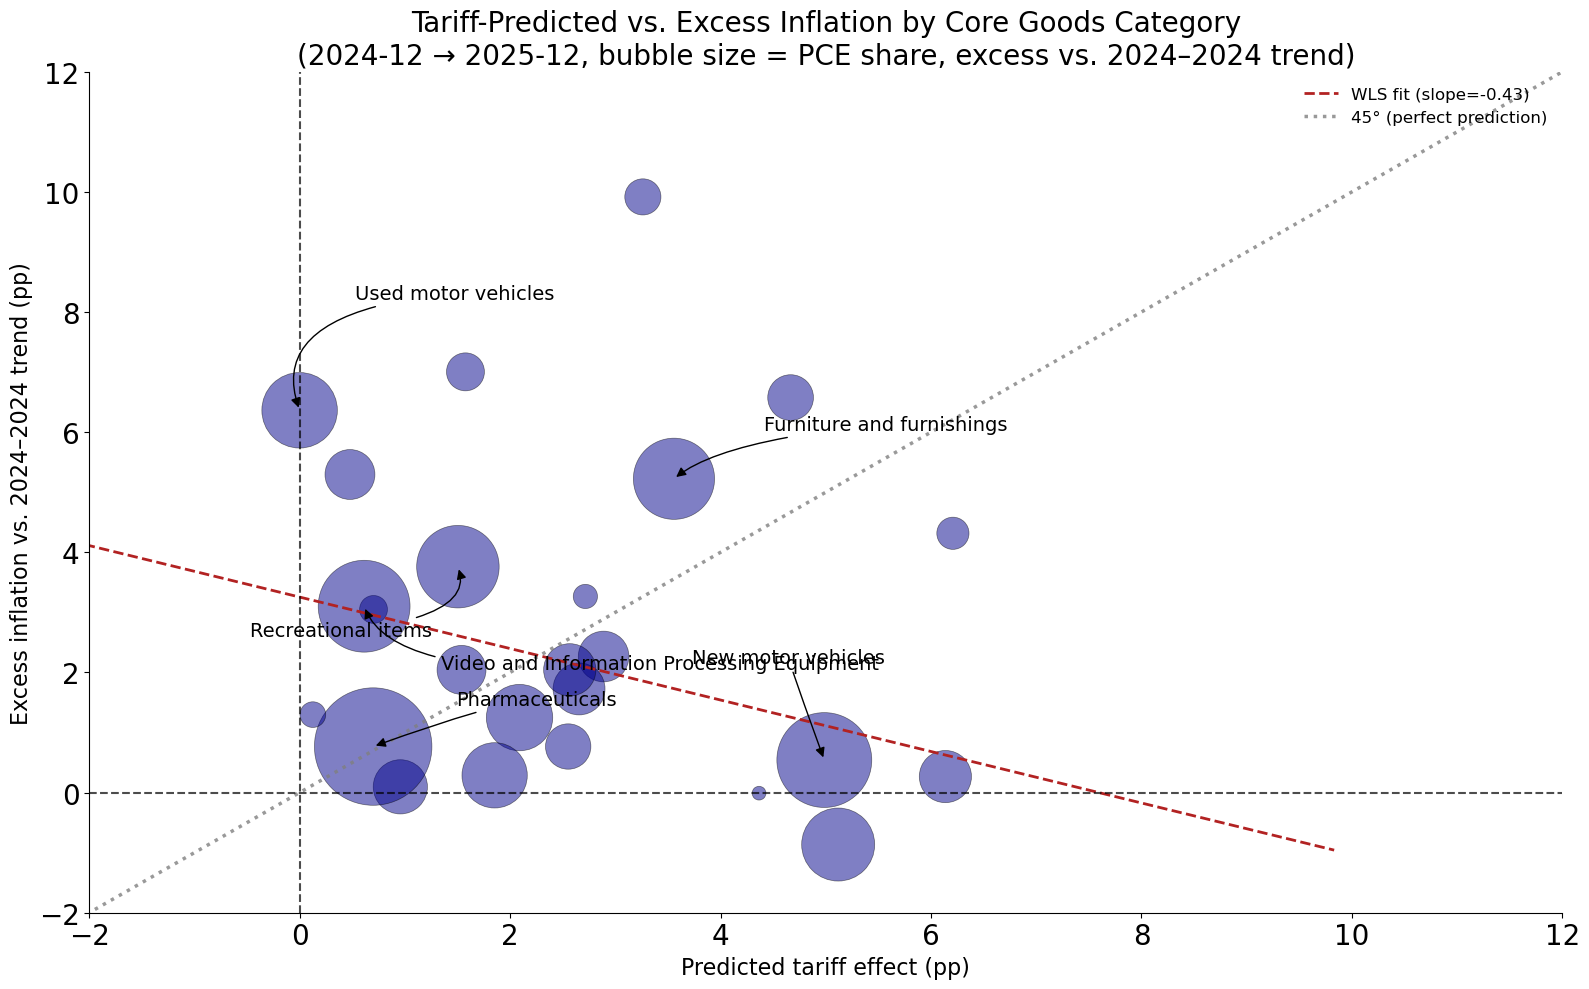

In [275]:

# ── Step 7c: Predicted tariff effect vs. excess inflation — scatter plot ──────
# Methodology §9
# Excess inflation = growth over the current window minus mean over the baseline window.
# Current window:  config.EXCESS_CURRENT_START_MONTH → config.EXCESS_CURRENT_END_MONTH
# Baseline window: config.EXCESS_BASELINE_START – config.EXCESS_BASELINE_END (inclusive).
# To adjust, change those values in config.py.


# print(
#     summary_df[['PCE_category', 'predicted_effect', 'excess_inflation', 'pce_share']]
#     .to_string(index=False)
# )

# ── Scatter plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 10))
plot_df = summary_df.dropna(subset=['predicted_effect', 'excess_inflation', 'pce_share'])

ax.scatter(
    plot_df['predicted_effect'] * 100,
    plot_df['excess_inflation'] * 100,
    s=plot_df['pce_share'] * 50000,
    alpha=0.5, color='darkblue', edgecolors='black', linewidths=0.5,
)

x = plot_df['predicted_effect'].values * 100
y = plot_df['excess_inflation'].values * 100
w = plot_df['pce_share'].values

wls_model  = sm.WLS(y, sm.add_constant(x), weights=w).fit()
intercept, slope = wls_model.params
print(wls_model.summary())

x_fit = np.linspace(x.min() - 3.5, x.max() + 3.5, 100)
ax.plot(x_fit, slope * x_fit + intercept,
        color='firebrick', linewidth=2, linestyle='--',
        label=f'WLS fit (slope={slope:.2f})')


# 45° perfect-prediction line
_xy_min = min(x.min(), y.min()) - 3.05
_xy_max = max(x.max(), y.max()) + 3.05
ax.plot([_xy_min, _xy_max], [_xy_min, _xy_max],
        color="gray", linewidth=2.5, linestyle=":", alpha=0.8, label="45° (perfect prediction)")

ax.axhline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.7)
ax.axvline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.7)


baseline_range = f"{config.EXCESS_BASELINE_START}–{config.EXCESS_BASELINE_END}"
current_window = f"{config.EXCESS_CURRENT_START_MONTH} → {config.EXCESS_CURRENT_END_MONTH}"
ax.set_title(
    f"Tariff-Predicted vs. Excess Inflation by Core Goods Category\n"
    f"({current_window}, bubble size = PCE share, excess vs. {baseline_range} trend)",
    fontsize=20,
)
ax.set_xlabel("Predicted tariff effect (pp)", fontsize=16)
ax.set_ylabel(f"Excess inflation vs. {baseline_range} trend (pp)", fontsize=16)
ax.legend(fontsize=12, frameon=False, loc='upper right')
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.set_xlim(-2.0, 12.0)
ax.set_ylim(-2.0, 12.0)

# ── Annotate top 5 categories by PCE share ────────────────────────────────────
# rank 0: Pharmaceutical and other medical products   xy=(0.70, -0.54)
# rank 1: New motor vehicles                          xy=(4.99,  0.13)
# rank 2: Video, audio, photographic, and info proc.  xy=(0.61,  9.13)
# rank 3: Recreational items                          xy=(1.50,  6.00)
# rank 4: Furniture and furnishings                   xy=(3.56,  5.68)
_top5 = plot_df.nlargest(5, "pce_share").reset_index(drop=True)

annotate_fontsize = 14

ax.annotate( # rank 0: pharmaceuticals
    "Pharmaceuticals",
    xy=(_top5.loc[0, "predicted_effect"] * 100, _top5.loc[0, "excess_inflation"] * 100),
    xycoords="data",
    xytext=(60, 30),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=20", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate( # rank 1: new motor vehicles
    _top5.loc[1, "PCE_category"],
    xy=(_top5.loc[1, "predicted_effect"] * 100, _top5.loc[1, "excess_inflation"] * 100),
    xycoords="data",
    xytext=(-95, 70),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate( # rank 2: video & info processing equipment
    "Video and Information Processing Equipment",  # Too long for the plot, so hardcoding a shorter label here
    xy=(_top5.loc[2, "predicted_effect"] * 100, _top5.loc[2, "excess_inflation"] * 100),
    xycoords="data",
    xytext=(55, -45),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate( # rank 3: recreational items
    _top5.loc[3, "PCE_category"],
    xy=(_top5.loc[3, "predicted_effect"] * 100, _top5.loc[3, "excess_inflation"] * 100),
    xycoords="data",
    xytext=(-150, -50),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate( # rank 4: furniture & furnishings
    _top5.loc[4, "PCE_category"],
    xy=(_top5.loc[4, "predicted_effect"] * 100, _top5.loc[4, "excess_inflation"] * 100),
    xycoords="data",
    xytext=(65, 35),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=40", "color": "black"},
    fontsize=annotate_fontsize,
)

# ── Annotate used motor vehicles ── xy=(0.00, 2.41) ───────────────────────────
_used_row = plot_df[plot_df['PCE_category'].str.contains('sed', case=False, na=False)].iloc[0]
ax.annotate(
    "Used motor vehicles",  # Too long for the plot, so hardcoding a shorter label here
    xy=(_used_row['predicted_effect'] * 100, _used_row['excess_inflation'] * 100),
    xycoords="data",
    xytext=(40, 80),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

plt.tight_layout()
plt.savefig("../figures/tariff_vs_excess_inflation.png", bbox_inches="tight", dpi=150)
plt.show()


                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.020
Model:                            WLS   Adj. R-squared:                 -0.021
Method:                 Least Squares   F-statistic:                    0.4857
Date:                Fri, 13 Mar 2026   Prob (F-statistic):              0.493
Time:                        12:58:21   Log-Likelihood:                -64.114
No. Observations:                  26   AIC:                             132.2
Df Residuals:                      24   BIC:                             134.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.6738      0.807      3.313      0.0

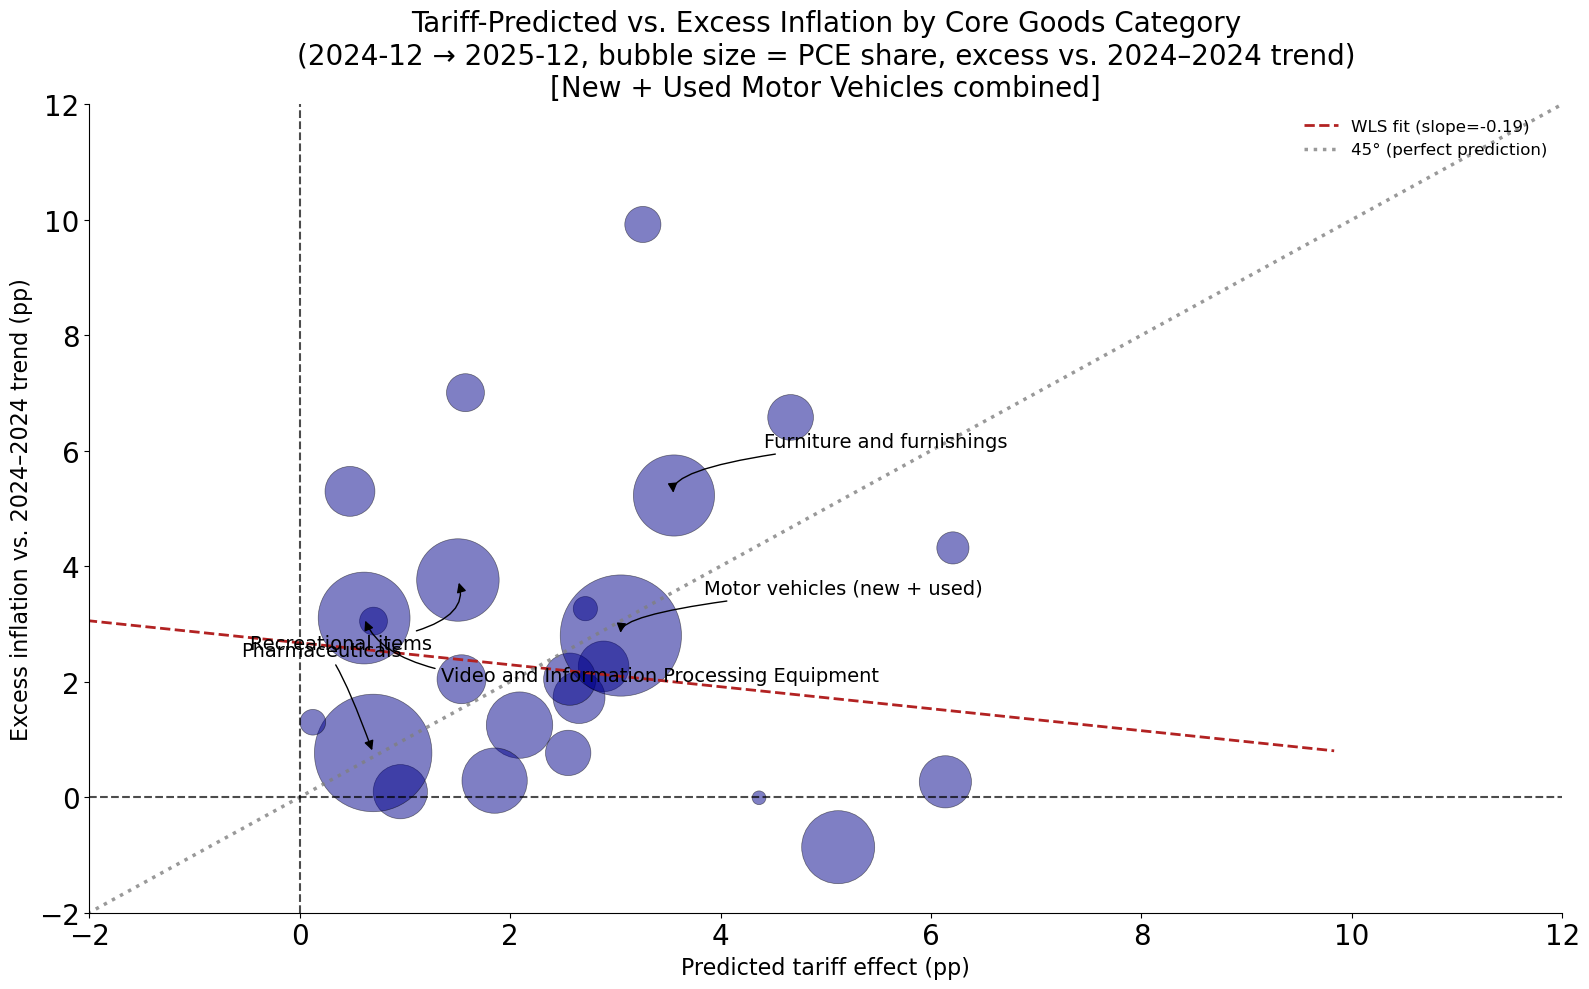


Top 5 annotated categories (by PCE share):
  rank 0: Motor vehicles (new + used)  (predicted=3.05pp, excess=2.80pp, pce_share=15.2%)
  rank 1: Pharmaceutical and other medical products  (predicted=0.70pp, excess=0.77pp, pce_share=14.3%)
  rank 2: Video, audio, photographic, and information processing equipment and media  (predicted=0.61pp, excess=3.10pp, pce_share=8.7%)
  rank 3: Recreational items  (predicted=1.50pp, excess=3.76pp, pce_share=7.1%)
  rank 4: Furniture and furnishings  (predicted=3.56pp, excess=5.22pp, pce_share=6.8%)


In [276]:

# ── Same scatter plot but with New + Used Motor Vehicles combined ─────────────
# Combines "New motor vehicles" and "Net purchases of used motor vehicles" into
# a single "Motor vehicles (new + used)" observation by averaging predicted_effect
# and excess_inflation weighted by pce_share, and summing pce_share.

plot_df2 = summary_df.dropna(subset=['predicted_effect', 'excess_inflation', 'pce_share']).copy()

_mv_mask = (
    plot_df2['PCE_category'].str.contains('New motor', case=False, na=False) |
    plot_df2['PCE_category'].str.contains('sed motor', case=False, na=False)
)
_mv = plot_df2[_mv_mask]
_combined_pce_share        = _mv['pce_share'].sum()
_combined_predicted_effect = (_mv['predicted_effect'] * _mv['pce_share']).sum() / _combined_pce_share
_combined_excess_inflation = (_mv['excess_inflation'] * _mv['pce_share']).sum() / _combined_pce_share

# Build combined row
_combined_row = pd.DataFrame([{
    'PCE_category':     'Motor vehicles (new + used)',
    'predicted_effect': _combined_predicted_effect,
    'excess_inflation': _combined_excess_inflation,
    'pce_share':        _combined_pce_share,
}])

# Drop the two individual motor-vehicle rows and append combined
plot_df2 = pd.concat(
    [plot_df2[~_mv_mask], _combined_row],
    ignore_index=True,
)

# ── Scatter ───────────────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(16, 10))

ax2.scatter(
    plot_df2['predicted_effect'] * 100,
    plot_df2['excess_inflation'] * 100,
    s=plot_df2['pce_share'] * 50000,
    alpha=0.5, color='darkblue', edgecolors='black', linewidths=0.5,
)

x2 = plot_df2['predicted_effect'].values * 100
y2 = plot_df2['excess_inflation'].values * 100
w2 = plot_df2['pce_share'].values

wls_model2 = sm.WLS(y2, sm.add_constant(x2), weights=w2).fit()
intercept2, slope2 = wls_model2.params
print(wls_model2.summary())

x_fit2 = np.linspace(x2.min() - 3.5, x2.max() + 3.5, 100)
ax2.plot(x_fit2, slope2 * x_fit2 + intercept2,
         color='firebrick', linewidth=2, linestyle='--',
         label=f'WLS fit (slope={slope2:.2f})')

_xy_min2 = min(x2.min(), y2.min()) - 3.05
_xy_max2 = max(x2.max(), y2.max()) + 3.05
ax2.plot([_xy_min2, _xy_max2], [_xy_min2, _xy_max2],
         color="gray", linewidth=2.5, linestyle=":", alpha=0.8, label="45° (perfect prediction)")

ax2.axhline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.7)
ax2.axvline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.7)

baseline_range2 = f"{config.EXCESS_BASELINE_START}–{config.EXCESS_BASELINE_END}"
current_window2 = f"{config.EXCESS_CURRENT_START_MONTH} → {config.EXCESS_CURRENT_END_MONTH}"
ax2.set_title(
    f"Tariff-Predicted vs. Excess Inflation by Core Goods Category\n"
    f"({current_window2}, bubble size = PCE share, excess vs. {baseline_range2} trend)\n"
    f"[New + Used Motor Vehicles combined]",
    fontsize=20,
)
ax2.set_xlabel("Predicted tariff effect (pp)", fontsize=16)
ax2.set_ylabel(f"Excess inflation vs. {baseline_range2} trend (pp)", fontsize=16)
ax2.legend(fontsize=12, frameon=False, loc='upper right')
ax2.tick_params(axis='x', labelsize=20)
ax2.tick_params(axis='y', labelsize=20)
ax2.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)

ax2.set_xlim(-2.0, 12.0)
ax2.set_ylim(-2.0, 12.0)

annotate_fontsize2 = 14

# ── Short-label lookup (for categories whose names are too long) ──────────────
def _short_label(cat):
    if 'Motor vehicles (new + used)' in cat:
        return 'Motor vehicles (new + used)'
    if 'harmaceutical' in cat:
        return 'Pharmaceuticals'
    if 'ideo' in cat:
        return 'Video and Information Processing Equipment'
    return cat

# ── Annotate top 5 by PCE share ───────────────────────────────────────────────
# After combining motor vehicles their merged share moves them to rank 0;
# all ranks are determined dynamically so labels always match the actual data.
_top5_2 = plot_df2.nlargest(5, "pce_share").reset_index(drop=True)

_offsets2 = [
    ( 60,  30),   # rank 0
    (-95,  70),   # rank 1
    ( 55, -45),   # rank 2
    (-150,-50),   # rank 3
    ( 65,  35),   # rank 4
]

for _rank, (_ox, _oy) in enumerate(_offsets2):
    _row2 = _top5_2.loc[_rank]
    ax2.annotate(
        _short_label(_row2["PCE_category"]),
        xy=(_row2["predicted_effect"] * 100, _row2["excess_inflation"] * 100),
        xycoords="data",
        xytext=(_ox, _oy),
        textcoords="offset points",
        horizontalalignment="left",
        arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
        fontsize=annotate_fontsize2,
    )

plt.tight_layout()
plt.savefig("../figures/tariff_vs_excess_inflation_mv_combined.png", bbox_inches="tight", dpi=150)
plt.show()

print("\nTop 5 annotated categories (by PCE share):")
for i, row in _top5_2.iterrows():
    print(f"  rank {i}: {row['PCE_category']}  "
          f"(predicted={row['predicted_effect']*100:.2f}pp, "
          f"excess={row['excess_inflation']*100:.2f}pp, "
          f"pce_share={row['pce_share']*100:.1f}%)")


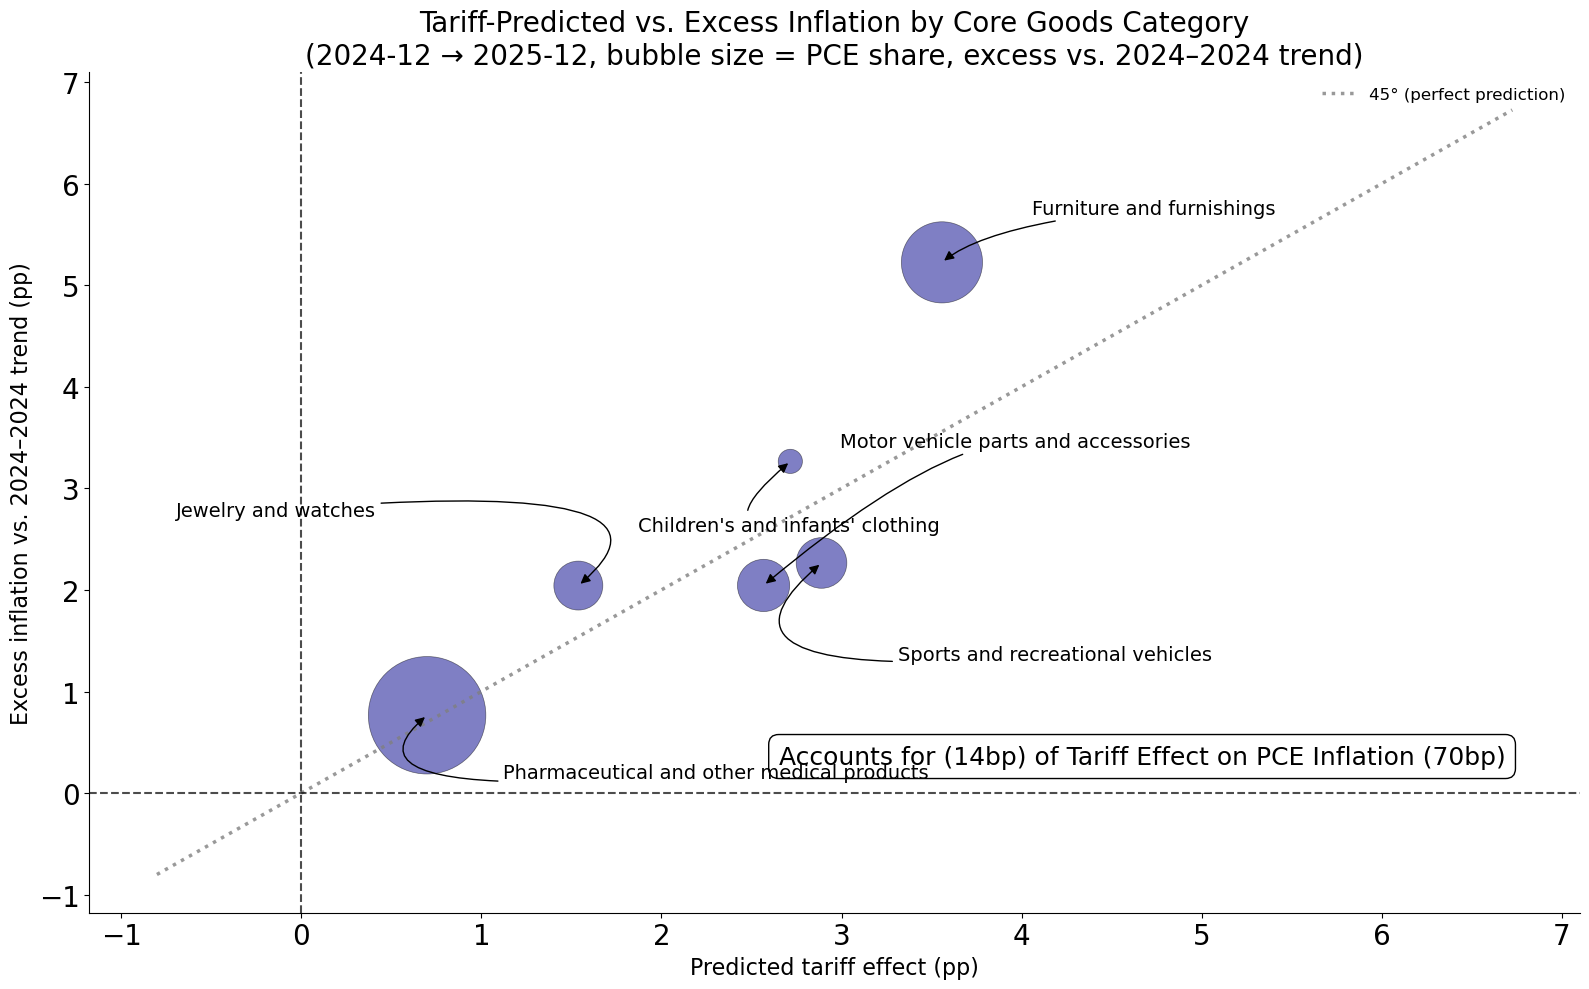

Furniture: Furniture and furnishings

Closest to 45° line:
                             PCE_category  predicted_effect  excess_inflation  _dist45
Pharmaceutical and other medical products               0.7               0.8      0.1
                      Jewelry and watches               1.5               2.0      0.5
      Motor vehicle parts and accessories               2.6               2.0      0.5
         Children's and infants' clothing               2.7               3.3      0.5
         Sports and recreational vehicles               2.9               2.3      0.6


In [277]:

# ── Furniture + 5 closest to 45° line only — no other dots, no WLS ────────────

plot_df = summary_df.dropna(subset=['predicted_effect', 'excess_inflation', 'pce_share'])

# ── Select the 6 observations to plot ─────────────────────────────────────────
_furn_mask = plot_df['PCE_category'].str.contains('urniture', case=False, na=False)
_furn_row  = plot_df[_furn_mask].iloc[0]

_other = plot_df[~_furn_mask].copy()
_other['_dist45'] = (_other['excess_inflation'] * 100 - _other['predicted_effect'] * 100).abs()
_closest5 = _other.nsmallest(5, '_dist45').reset_index(drop=True)

# Slice the furniture row as a 1-row DataFrame (preserves dtypes)
_plot6 = pd.concat([plot_df[_furn_mask], _closest5.drop(columns='_dist45')], ignore_index=True)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 10))

ax.scatter(
    _plot6['predicted_effect'] * 100,
    _plot6['excess_inflation'] * 100,
    s=_plot6['pce_share'] * 50000,
    alpha=0.5, color='darkblue', edgecolors='black', linewidths=0.5,
)

# 45° perfect-prediction line
_all_vals = pd.concat([_plot6['predicted_effect'], _plot6['excess_inflation']]) * 100
_xy_min = _all_vals.min() - 1.5
_xy_max = _all_vals.max() + 1.5
ax.plot([_xy_min, _xy_max], [_xy_min, _xy_max],
        color="gray", linewidth=2.5, linestyle=":", alpha=0.8, label="45° (perfect prediction)")

ax.axhline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.7)
ax.axvline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.7)

baseline_range = f"{config.EXCESS_BASELINE_START}–{config.EXCESS_BASELINE_END}"
current_window = f"{config.EXCESS_CURRENT_START_MONTH} → {config.EXCESS_CURRENT_END_MONTH}"
ax.set_title(
    f"Tariff-Predicted vs. Excess Inflation by Core Goods Category\n"
    f"({current_window}, bubble size = PCE share, excess vs. {baseline_range} trend)",
    fontsize=20,
)
ax.set_xlabel("Predicted tariff effect (pp)", fontsize=16)
ax.set_ylabel(f"Excess inflation vs. {baseline_range} trend (pp)", fontsize=16)
ax.legend(fontsize=12, frameon=False, loc='upper right')
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

annotate_fontsize = 14

ax.text(
    0.95, 0.2,
    f"Accounts for (14bp) of Tariff Effect on PCE Inflation (70bp)",
    transform=ax.transAxes,
    fontsize=18,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black", linewidth=1),
)

# ── Annotate Furniture ── xy=(3.56, 5.68) ────────────────────────────────────
ax.annotate(
    _furn_row['PCE_category'],
    xy=(_furn_row['predicted_effect'] * 100, _furn_row['excess_inflation'] * 100),
    xycoords="data",
    xytext=(65, 35),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=40", "color": "black"},
    fontsize=annotate_fontsize,
)

# ── Annotate the 5 closest-to-45° categories ─────────────────────────────────
# rank 0: Personal care products            xy=(2.09, 2.16)
# rank 1: Motor vehicle parts & accessories  xy=(2.57, 2.81)
# rank 2: Children's and infants' clothing  xy=(2.72, 3.04)
# rank 3: Household supplies                xy=(1.85, 1.21)
# rank 4: Musical instruments               xy=(4.37, 3.66)
_offsets = [
    ( 55, -45),   # rank 0: Personal care products
    (-290,  50),  # rank 1: Motor vehicle parts and accessories
    ( 55,  100),   # rank 2: Children's and infants' clothing
    (-110, -50),  # rank 3: Household supplies
    ( 55,  -70),  # rank 4: Musical instruments
]
for i, row in _closest5.iterrows():
    _ox, _oy = _offsets[i]
    ax.annotate(
        row['PCE_category'],
        xy=(row['predicted_effect'] * 100, row['excess_inflation'] * 100),
        xycoords="data",
        xytext=(_ox, _oy),
        textcoords="offset points",
        horizontalalignment="left",
        arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=40", "color": "black"},
        fontsize=annotate_fontsize,
    )

plt.tight_layout()
plt.savefig("../figures/tariff_vs_excess_inflation_furniture_45.png", bbox_inches="tight", dpi=150)
plt.show()

# ── Print annotated categories ────────────────────────────────────────────────
print(f"Furniture: {_furn_row['PCE_category']}")
print("\nClosest to 45° line:")
print(
    _closest5[['PCE_category', 'predicted_effect', 'excess_inflation', '_dist45']]
    .assign(
        predicted_effect=lambda d: d['predicted_effect'] * 100,
        excess_inflation=lambda d: d['excess_inflation'] * 100,
    )
    .to_string(index=False)
)


In [278]:

# ── How much do Furniture + the 5 closest-to-45° categories account for? ──────
# All quantities in basis points (bps) = proportion × 10000.
#
# pce_share   = category's weight in core goods PCE basket (sums to ~1)
# _cg_share   = core goods share of core PCE (from step 7a)
# window      = config.EXCESS_CURRENT_START_MONTH → EXCESS_CURRENT_END_MONTH

_cg_share            = result['core_goods_share']
_actual_core_pce_bps = result['actual_inflation'] * 10000   # e.g. 300 bps
_baseline_m          = config.COUNTERFACTUAL_BASELINE_MONTH
_current_m           = config.TARIFF_CURRENT_MONTH

_6cats = _plot6[['PCE_category', 'pce_share', 'inflation_current', 'predicted_effect']].copy()

# ── Per-category rates and contributions (all in bps) ─────────────────────────
# Rate (bps): how much did this category's price change?
_6cats['actual_rate_bps']     = _6cats['inflation_current'] * 10000
_6cats['predicted_rate_bps']  = _6cats['predicted_effect']  * 10000
_6cats['pce_share_pct']       = _6cats['pce_share']         * 100

# Contribution to core goods inflation (bps) = weight × rate (in bps)
_6cats['actual_contrib_cg_bps']    = _6cats['pce_share'] * _6cats['actual_rate_bps']
_6cats['predicted_contrib_cg_bps'] = _6cats['pce_share'] * _6cats['predicted_rate_bps']

# Contribution to core PCE inflation (bps) = core goods contribution × core goods share
_6cats['actual_contrib_pce_bps']    = _6cats['actual_contrib_cg_bps']    * _cg_share
_6cats['predicted_contrib_pce_bps'] = _6cats['predicted_contrib_cg_bps'] * _cg_share

# ── Totals for these 6 categories ────────────────────────────────────────────
_6_actual_cg_bps     = _6cats['actual_contrib_cg_bps'].sum()
_6_predicted_cg_bps  = _6cats['predicted_contrib_cg_bps'].sum()
_6_actual_pce_bps    = _6cats['actual_contrib_pce_bps'].sum()
_6_predicted_pce_bps = _6cats['predicted_contrib_pce_bps'].sum()

# ── Totals for ALL core goods categories ──────────────────────────────────────
_all_actual_cg_bps     = (summary_df['pce_share'] * summary_df['inflation_current'] * 10000).sum()
_all_predicted_cg_bps  = (summary_df['pce_share'] * summary_df['predicted_effect']  * 10000).sum()
_all_actual_pce_bps    = _all_actual_cg_bps    * _cg_share
_all_predicted_pce_bps = _all_predicted_cg_bps * _cg_share

# ── Category-level table ──────────────────────────────────────────────────────
_out6 = (
    _6cats[['PCE_category', 'pce_share_pct',
            'actual_rate_bps',    'actual_contrib_cg_bps',    'actual_contrib_pce_bps',
            'predicted_rate_bps', 'predicted_contrib_cg_bps', 'predicted_contrib_pce_bps']]
    .rename(columns={
        'PCE_category':             'Category',
        'pce_share_pct':            'Wt in core goods (%)',
        'actual_rate_bps':          'Actual infl. (bps)',
        'actual_contrib_cg_bps':    'Contrib → core goods (bps)',
        'actual_contrib_pce_bps':   'Contrib → core PCE (bps)',
        'predicted_rate_bps':       'Predicted tariff (bps)',
        'predicted_contrib_cg_bps': 'Predicted → core goods (bps)',
        'predicted_contrib_pce_bps':'Predicted → core PCE (bps)',
    })
    .reset_index(drop=True)
)
pd.set_option("display.float_format", "{:.1f}".format)
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 10)
display(_out6)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'─'*68}")
print(f"  Accounting summary  ({_baseline_m} → {_current_m})   [all figures in bps]")
print(f"{'─'*68}")
print(f"  {'':42}  {'Core goods':>10}  {'Core PCE':>10}")
print(f"  {'─'*62}")
print(f"  {'Actual inflation — ALL core goods':42}  {_all_actual_cg_bps:>10.0f}  {_all_actual_pce_bps:>10.0f}")
print(f"  {'Predicted tariff effect — ALL core goods':42}  {_all_predicted_cg_bps:>10.0f}  {_all_predicted_pce_bps:>10.0f}")
print(f"  {'─'*62}")
print(f"  {'Actual inflation — these 6 categories':42}  {_6_actual_cg_bps:>10.0f}  {_6_actual_pce_bps:>10.0f}")
print(f"  {'Predicted tariff effect — these 6 categories':42}  {_6_predicted_cg_bps:>10.0f}  {_6_predicted_pce_bps:>10.0f}")
print(f"  {'─'*62}")
print(f"  {'Actual core PCE inflation (incl. services)':42}  {'—':>10}  {_actual_core_pce_bps:>10.0f}")
print(f"  {'─'*62}")
print(f"  6-cat predicted as share of total tariff signal: "
      f"{_6_predicted_pce_bps/_all_predicted_pce_bps:.1%}")
print(f"  6-cat predicted as share of actual core PCE:     "
      f"{_6_predicted_pce_bps/_actual_core_pce_bps:.1%}")
print(f"  {'─'*62}")
print(f"  Memo — core goods share of core PCE:  {_cg_share*100:.1f}%")


,Category,Wt in core goods (%),Actual infl. (bps),Contrib → core goods (bps),Contrib → core PCE (bps),Predicted tariff (bps),Predicted → core goods (bps),Predicted → core PCE (bps)
0,Furniture and furnishings,6.8,418.1,28.6,6.5,355.8,24.3,5.5
1,Pharmaceutical and other medical products,14.3,158.9,22.7,5.2,69.9,10.0,2.3
2,Jewelry and watches,2.5,395.5,9.8,2.2,153.9,3.8,0.9
3,Motor vehicle parts and accessories,2.8,357.0,10.1,2.3,256.7,7.3,1.7
4,Children's and infants' clothing,0.6,306.4,1.9,0.4,271.6,1.7,0.4
5,Sports and recreational vehicles,2.7,75.2,2.0,0.5,288.9,7.7,1.7



────────────────────────────────────────────────────────────────────
  Accounting summary  (2024-12 → 2025-12)   [all figures in bps]
────────────────────────────────────────────────────────────────────
                                              Core goods    Core PCE
  ──────────────────────────────────────────────────────────────
  Actual inflation — ALL core goods                  199          45
  Predicted tariff effect — ALL core goods           244          55
  ──────────────────────────────────────────────────────────────
  Actual inflation — these 6 categories               75          17
  Predicted tariff effect — these 6 categories          55          12
  ──────────────────────────────────────────────────────────────
  Actual core PCE inflation (incl. services)           —         301
  ──────────────────────────────────────────────────────────────
  6-cat predicted as share of total tariff signal: 22.4%
  6-cat predicted as share of actual core PCE:     4.1%
  ─────

In [279]:

# ── PCE accounting: Video + Used Motor Vehicles + Recreational Items ──────────
# Same methodology as the 6-category cell above, but restricted to these 3 cats:
#   (1) Video, audio, photographic, and information processing equipment
#   (2) Net purchases of used motor vehicles
#   (3) Recreational items
# All quantities in basis points (bps) = proportion × 10000.

_3cats_mask = (
    summary_df['PCE_category'].str.contains('ideo', case=False, na=False) |
    summary_df['PCE_category'].str.contains('sed', case=False, na=False)  |
    summary_df['PCE_category'].str.contains('ecreational', case=False, na=False)
)
_plot3 = summary_df[_3cats_mask].copy().reset_index(drop=True)
print("Selected categories:")
print(_plot3['PCE_category'].tolist())

_cg_share3            = result['core_goods_share']
_actual_core_pce_bps3 = result['actual_inflation'] * 10000

_3df = _plot3[['PCE_category', 'pce_share', 'inflation_current', 'predicted_effect']].copy()

_3df['actual_rate_bps']     = _3df['inflation_current'] * 10000
_3df['predicted_rate_bps']  = _3df['predicted_effect']  * 10000
_3df['pce_share_pct']       = _3df['pce_share']         * 100

_3df['actual_contrib_cg_bps']    = _3df['pce_share'] * _3df['actual_rate_bps']
_3df['predicted_contrib_cg_bps'] = _3df['pce_share'] * _3df['predicted_rate_bps']

_3df['actual_contrib_pce_bps']    = _3df['actual_contrib_cg_bps']    * _cg_share3
_3df['predicted_contrib_pce_bps'] = _3df['predicted_contrib_cg_bps'] * _cg_share3

_3_actual_cg_bps     = _3df['actual_contrib_cg_bps'].sum()
_3_predicted_cg_bps  = _3df['predicted_contrib_cg_bps'].sum()
_3_actual_pce_bps    = _3df['actual_contrib_pce_bps'].sum()
_3_predicted_pce_bps = _3df['predicted_contrib_pce_bps'].sum()

_all_actual_cg_bps3     = (summary_df['pce_share'] * summary_df['inflation_current'] * 10000).sum()
_all_predicted_cg_bps3  = (summary_df['pce_share'] * summary_df['predicted_effect']  * 10000).sum()
_all_actual_pce_bps3    = _all_actual_cg_bps3    * _cg_share3
_all_predicted_pce_bps3 = _all_predicted_cg_bps3 * _cg_share3

_out3 = (
    _3df[['PCE_category', 'pce_share_pct',
          'actual_rate_bps',    'actual_contrib_cg_bps',    'actual_contrib_pce_bps',
          'predicted_rate_bps', 'predicted_contrib_cg_bps', 'predicted_contrib_pce_bps']]
    .rename(columns={
        'PCE_category':              'Category',
        'pce_share_pct':             'Wt in core goods (%)',
        'actual_rate_bps':           'Actual infl. (bps)',
        'actual_contrib_cg_bps':     'Contrib → core goods (bps)',
        'actual_contrib_pce_bps':    'Contrib → core PCE (bps)',
        'predicted_rate_bps':        'Predicted tariff (bps)',
        'predicted_contrib_cg_bps':  'Predicted → core goods (bps)',
        'predicted_contrib_pce_bps': 'Predicted → core PCE (bps)',
    })
    .reset_index(drop=True)
)
pd.set_option("display.float_format", "{:.1f}".format)
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 10)
display(_out3)

_baseline_m3 = config.COUNTERFACTUAL_BASELINE_MONTH
_current_m3  = config.TARIFF_CURRENT_MONTH

print(f"\n{'─'*68}")
print(f"  Accounting summary  ({_baseline_m3} → {_current_m3})   [all figures in bps]")
print(f"{'─'*68}")
print(f"  {'':42}  {'Core goods':>10}  {'Core PCE':>10}")
print(f"  {'─'*62}")
print(f"  {'Actual inflation — ALL core goods':42}  {_all_actual_cg_bps3:>10.0f}  {_all_actual_pce_bps3:>10.0f}")
print(f"  {'Predicted tariff effect — ALL core goods':42}  {_all_predicted_cg_bps3:>10.0f}  {_all_predicted_pce_bps3:>10.0f}")
print(f"  {'─'*62}")
print(f"  {'Actual inflation — these 3 categories':42}  {_3_actual_cg_bps:>10.0f}  {_3_actual_pce_bps:>10.0f}")
print(f"  {'Predicted tariff effect — these 3 categories':42}  {_3_predicted_cg_bps:>10.0f}  {_3_predicted_pce_bps:>10.0f}")
print(f"  {'─'*62}")
print(f"  {'Actual core PCE inflation (incl. services)':42}  {'—':>10}  {_actual_core_pce_bps3:>10.0f}")
print(f"  {'─'*62}")
print(f"  3-cat predicted as share of total tariff signal: "
      f"{_3_predicted_pce_bps/_all_predicted_pce_bps3:.1%}")
print(f"  3-cat predicted as share of actual core PCE:     "
      f"{_3_predicted_pce_bps/_actual_core_pce_bps3:.1%}")
print(f"  3-cat actual as share of actual core PCE:        "
      f"{_3_actual_pce_bps/_actual_core_pce_bps3:.1%}")
print(f"  {'─'*62}")
print(f"  Memo — core goods share of core PCE:  {_cg_share3*100:.1f}%")


Selected categories:
['Sports and recreational vehicles', 'Recreational items', 'Video, audio, photographic, and information processing equipment and media', 'Recreational books', 'Net purchases of used motor vehicles']


,Category,Wt in core goods (%),Actual infl. (bps),Contrib → core goods (bps),Contrib → core PCE (bps),Predicted tariff (bps),Predicted → core goods (bps),Predicted → core PCE (bps)
0,Sports and recreational vehicles,2.7,75.2,2.0,0.5,288.9,7.7,1.7
1,Recreational items,7.1,276.2,19.5,4.4,150.4,10.6,2.4
2,"Video, audio, photographic, and information pr...",8.7,271.1,23.7,5.4,61.3,5.4,1.2
3,Recreational books,0.7,80.8,0.6,0.1,12.6,0.1,0.0
4,Net purchases of used motor vehicles,5.9,161.9,9.6,2.2,0.0,0.0,0.0



────────────────────────────────────────────────────────────────────
  Accounting summary  (2024-12 → 2025-12)   [all figures in bps]
────────────────────────────────────────────────────────────────────
                                              Core goods    Core PCE
  ──────────────────────────────────────────────────────────────
  Actual inflation — ALL core goods                  199          45
  Predicted tariff effect — ALL core goods           244          55
  ──────────────────────────────────────────────────────────────
  Actual inflation — these 3 categories               55          13
  Predicted tariff effect — these 3 categories          24           5
  ──────────────────────────────────────────────────────────────
  Actual core PCE inflation (incl. services)           —         301
  ──────────────────────────────────────────────────────────────
  3-cat predicted as share of total tariff signal: 9.7%
  3-cat predicted as share of actual core PCE:     1.8%
  3-cat 

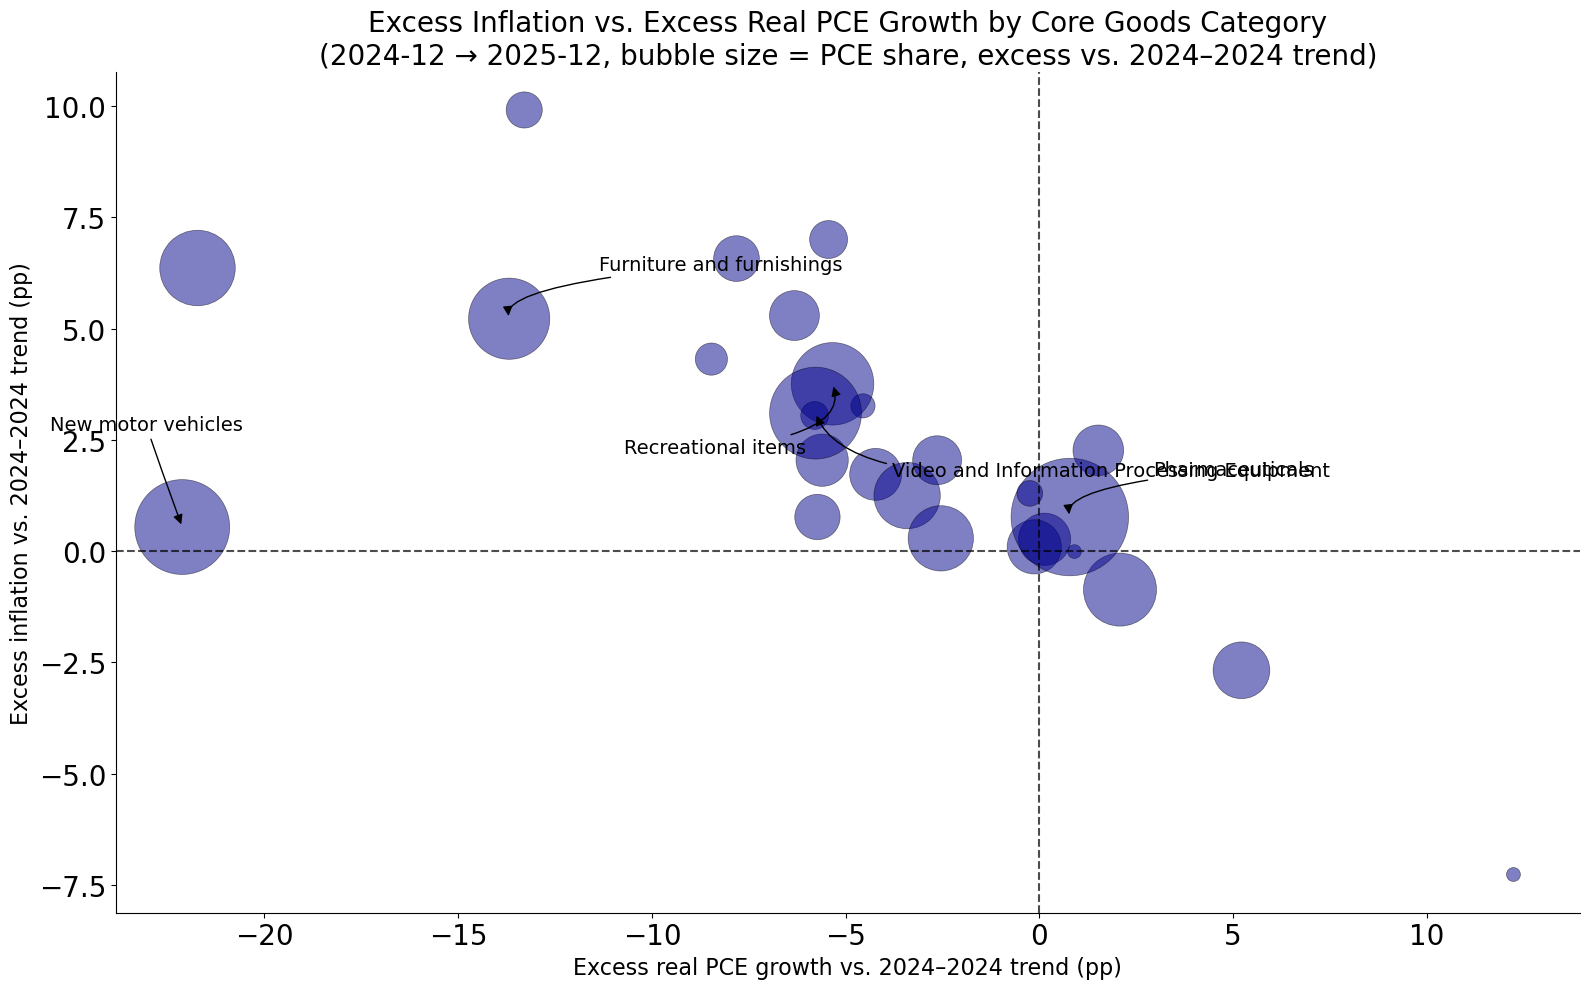

                                                              PCE_category  excess_real_pce_pp  excess_inflation_pp  pce_share_pct
                                 Pharmaceutical and other medical products                 0.8                  0.8           14.3
                                                        New motor vehicles               -22.1                  0.5            9.3
Video, audio, photographic, and information processing equipment and media                -5.8                  3.1            8.7
                                                        Recreational items                -5.3                  3.8            7.1
                                                 Furniture and furnishings               -13.7                  5.2            6.8
                                      Net purchases of used motor vehicles               -21.7                  6.4            5.9
                                               Women's and girls' clothing         

In [280]:

# ── Excess inflation vs. excess real PCE growth — scatter plot ────────────────
# Downloads U20403 (real PCE quantity indexes, NIUnderlyingDetail) and computes
# excess real consumption growth over the identical window used for excess inflation.
#
# Interpretation:
#   Upper-left  (high inflation, low real growth)  → supply-side cost push (tariff-like)
#   Upper-right (high inflation, high real growth) → demand-driven or mix
#   Lower-right (low inflation,  high real growth) → supply expansion / disinflation
#
# All baseline/current window settings come from config.py.

import requests

# ── Pull U20403 (real PCE quantity indexes, underlying detail) ────────────────
_start_year  = int(config.EXCESS_CURRENT_START_MONTH[:4])
_end_year    = int(config.EXCESS_CURRENT_END_MONTH[:4])
_start_mm    = config.EXCESS_CURRENT_START_MONTH[5:]
_end_mm      = config.EXCESS_CURRENT_END_MONTH[5:]
_year_offset = _end_year - _start_year

_baseline_years = list(range(config.EXCESS_BASELINE_START, config.EXCESS_BASELINE_END + 1))
_data_years = sorted(set(
    [y - _year_offset for y in _baseline_years]
    + _baseline_years
    + [_start_year, _end_year]
))
_year_str_q = ",".join(str(y) for y in _data_years)

_r_q = requests.get(
    "https://apps.bea.gov/api/data"
    f"?UserID={config.BEA_KEY}"
    "&method=GetData"
    "&DataSetName=NIUnderlyingDetail"
    "&TableName=U20403"
    "&Frequency=M"
    f"&Year={_year_str_q}"
    "&ResultFormat=json"
)
_r_q.raise_for_status()
_hist_q = pd.DataFrame(_r_q.json()["BEAAPI"]["Results"]["Data"])
_hist_q["DataValue"] = pd.to_numeric(_hist_q["DataValue"], errors="coerce")
_hist_q["TimePeriod"] = _hist_q["TimePeriod"].str.replace("M", "-", regex=False)

_bea_names = list(config.NIPA_CROSSWALK.values())
_hist_q = _hist_q[_hist_q["LineDescription"].isin(_bea_names)]
_hist_q_wide = _hist_q.pivot(index="LineDescription", columns="TimePeriod", values="DataValue")

# ── Current window real PCE growth ────────────────────────────────────────────
_real_pce_current = (
    _hist_q_wide[config.EXCESS_CURRENT_END_MONTH]
    / _hist_q_wide[config.EXCESS_CURRENT_START_MONTH]
    - 1
)

# ── Baseline average real PCE growth (same calendar window, shifted to baseline years) ──
_baseline_real_rates = {}
for _y in _baseline_years:
    _bs = f"{_y - _year_offset}-{_start_mm}"
    _be = f"{_y}-{_end_mm}"
    if _bs in _hist_q_wide.columns and _be in _hist_q_wide.columns:
        _baseline_real_rates[_y] = _hist_q_wide[_be] / _hist_q_wide[_bs] - 1

if _baseline_real_rates:
    _baseline_real_pce = pd.concat(_baseline_real_rates, axis=1).mean(axis=1)
else:
    _baseline_real_pce = pd.Series(0.0, index=_hist_q_wide.index)

_excess_real_pce = _real_pce_current - _baseline_real_pce

# ── Merge onto summary_df ─────────────────────────────────────────────────────
_q_plot = summary_df.copy()
_q_plot["excess_real_pce"] = _q_plot["bea_name"].map(_excess_real_pce)
_q_plot = _q_plot.dropna(subset=["excess_inflation", "excess_real_pce", "pce_share"])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig_q, ax_q = plt.subplots(figsize=(16, 10))

ax_q.scatter(
    _q_plot["excess_real_pce"] * 100,
    _q_plot["excess_inflation"] * 100,
    s=_q_plot["pce_share"] * 50000,
    alpha=0.5, color="darkblue", edgecolors="black", linewidths=0.5,
)

ax_q.axhline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)
ax_q.axvline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)

_baseline_range_q = f"{config.EXCESS_BASELINE_START}–{config.EXCESS_BASELINE_END}"
_current_window_q = f"{config.EXCESS_CURRENT_START_MONTH} → {config.EXCESS_CURRENT_END_MONTH}"
ax_q.set_title(
    f"Excess Inflation vs. Excess Real PCE Growth by Core Goods Category\n"
    f"({_current_window_q}, bubble size = PCE share, excess vs. {_baseline_range_q} trend)",
    fontsize=20,
)
ax_q.set_xlabel(f"Excess real PCE growth vs. {_baseline_range_q} trend (pp)", fontsize=16)
ax_q.set_ylabel(f"Excess inflation vs. {_baseline_range_q} trend (pp)", fontsize=16)
ax_q.tick_params(axis="x", labelsize=20)
ax_q.tick_params(axis="y", labelsize=20)
ax_q.spines["right"].set_visible(False)
ax_q.spines["top"].set_visible(False)

# ── Short-label helper ────────────────────────────────────────────────────────
def _short_label_q(cat):
    if "harmaceutical" in cat:
        return "Pharmaceuticals"
    if "ideo" in cat:
        return "Video and Information Processing Equipment"
    return cat

# ── Annotate top 5 by PCE share ───────────────────────────────────────────────
_top5_q = _q_plot.nlargest(5, "pce_share").reset_index(drop=True)
_offsets_q = [(60, 30), (-95, 70), (55, -45), (-150, -50), (65, 35)]

for _rank, (_ox, _oy) in enumerate(_offsets_q):
    _row_q = _top5_q.loc[_rank]
    ax_q.annotate(
        _short_label_q(_row_q["PCE_category"]),
        xy=(_row_q["excess_real_pce"] * 100, _row_q["excess_inflation"] * 100),
        xycoords="data",
        xytext=(_ox, _oy),
        textcoords="offset points",
        horizontalalignment="left",
        arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
        fontsize=14,
    )

plt.tight_layout()
plt.savefig("../figures/excess_inflation_vs_excess_real_pce.png", bbox_inches="tight", dpi=150)
plt.show()

# ── Print data table ──────────────────────────────────────────────────────────
print(
    _q_plot[["PCE_category", "excess_real_pce", "excess_inflation", "pce_share"]]
    .assign(
        excess_real_pce_pp  = lambda d: d["excess_real_pce"]  * 100,
        excess_inflation_pp = lambda d: d["excess_inflation"] * 100,
        pce_share_pct       = lambda d: d["pce_share"]        * 100,
    )
    [["PCE_category", "excess_real_pce_pp", "excess_inflation_pp", "pce_share_pct"]]
    .sort_values("pce_share_pct", ascending=False)
    .to_string(index=False)
)


                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.334
Model:                            WLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     12.55
Date:                Fri, 13 Mar 2026   Prob (F-statistic):            0.00159
Time:                        12:58:24   Log-Likelihood:                -63.548
No. Observations:                  27   AIC:                             131.1
Df Residuals:                      25   BIC:                             133.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3450      0.667      0.517      0.6

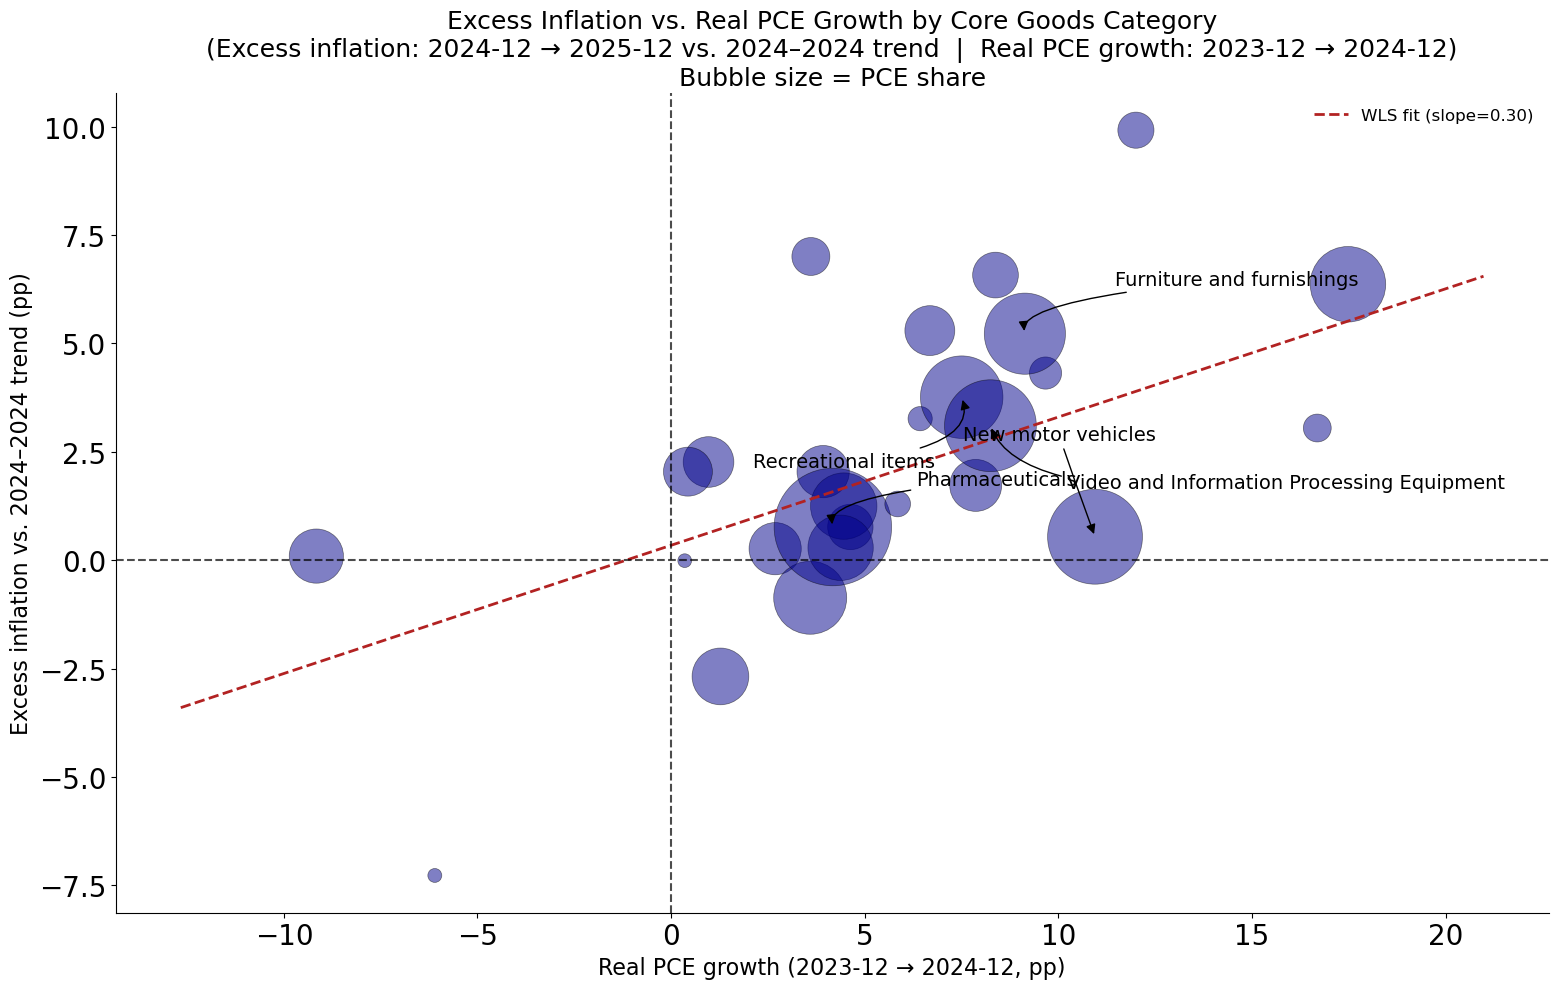

                                                              PCE_category  real_pce_growth_pp  excess_inflation_pp  pce_share_pct
                                 Pharmaceutical and other medical products                 4.2                  0.8           14.3
                                                        New motor vehicles                10.9                  0.5            9.3
Video, audio, photographic, and information processing equipment and media                 8.2                  3.1            8.7
                                                        Recreational items                 7.5                  3.8            7.1
                                                 Furniture and furnishings                 9.1                  5.2            6.8
                                      Net purchases of used motor vehicles                17.5                  6.4            5.9
                                               Women's and girls' clothing         

In [281]:

# ── Excess inflation vs. actual real PCE growth — scatter plot ────────────────
# Y-axis: excess inflation (same series as existing scatter, from summary_df)
# X-axis: actual real PCE growth over config.REAL_PCE_GROWTH_START_MONTH →
#         config.REAL_PCE_GROWTH_END_MONTH  (NOT differenced vs. a baseline)
#
# To change the real PCE growth window, edit REAL_PCE_GROWTH_START_MONTH and
# REAL_PCE_GROWTH_END_MONTH in config.py —  no changes to this cell needed.

import requests

# ── Pull U20403 for the real PCE growth window ────────────────────────────────
_rpce_start = config.REAL_PCE_GROWTH_START_MONTH
_rpce_end   = config.REAL_PCE_GROWTH_END_MONTH
_rpce_years = sorted({int(_rpce_start[:4]), int(_rpce_end[:4])})
_rpce_year_str = ",".join(str(y) for y in _rpce_years)

_r_rpce = requests.get(
    "https://apps.bea.gov/api/data"
    f"?UserID={config.BEA_KEY}"
    "&method=GetData"
    "&DataSetName=NIUnderlyingDetail"
    "&TableName=U20403"
    "&Frequency=M"
    f"&Year={_rpce_year_str}"
    "&ResultFormat=json"
)
_r_rpce.raise_for_status()
_hist_rpce = pd.DataFrame(_r_rpce.json()["BEAAPI"]["Results"]["Data"])
_hist_rpce["DataValue"] = pd.to_numeric(_hist_rpce["DataValue"], errors="coerce")
_hist_rpce["TimePeriod"] = _hist_rpce["TimePeriod"].str.replace("M", "-", regex=False)

_bea_names_rpce = list(config.NIPA_CROSSWALK.values())
_hist_rpce = _hist_rpce[_hist_rpce["LineDescription"].isin(_bea_names_rpce)]
_hist_rpce_wide = _hist_rpce.pivot(
    index="LineDescription", columns="TimePeriod", values="DataValue"
)

# ── Actual real PCE growth (start → end, no baseline subtraction) ─────────────
_real_pce_growth = (
    _hist_rpce_wide[_rpce_end] / _hist_rpce_wide[_rpce_start] - 1
)

# ── Merge onto summary_df ─────────────────────────────────────────────────────
_rpce_plot = summary_df.copy()
_rpce_plot["real_pce_growth"] = _rpce_plot["bea_name"].map(_real_pce_growth)
_rpce_plot = _rpce_plot.dropna(subset=["excess_inflation", "real_pce_growth", "pce_share"])

# ── WLS fit ───────────────────────────────────────────────────────────────────
_x_rpce = _rpce_plot["real_pce_growth"].values  * 100
_y_rpce = _rpce_plot["excess_inflation"].values * 100
_w_rpce = _rpce_plot["pce_share"].values

wls_rpce = sm.WLS(_y_rpce, sm.add_constant(_x_rpce), weights=_w_rpce).fit()
_intercept_rpce, _slope_rpce = wls_rpce.params
print(wls_rpce.summary())

# ── Plot ──────────────────────────────────────────────────────────────────────
fig_rpce, ax_rpce = plt.subplots(figsize=(16, 10))

ax_rpce.scatter(
    _rpce_plot["real_pce_growth"] * 100,
    _rpce_plot["excess_inflation"] * 100,
    s=_rpce_plot["pce_share"] * 50000,
    alpha=0.5, color="darkblue", edgecolors="black", linewidths=0.5,
)

_x_fit_rpce = np.linspace(_x_rpce.min() - 3.5, _x_rpce.max() + 3.5, 100)
ax_rpce.plot(_x_fit_rpce, _slope_rpce * _x_fit_rpce + _intercept_rpce,
             color='firebrick', linewidth=2, linestyle='--',
             label=f'WLS fit (slope={_slope_rpce:.2f})')

ax_rpce.axhline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)
ax_rpce.axvline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)

_baseline_range_rpce = f"{config.EXCESS_BASELINE_START}–{config.EXCESS_BASELINE_END}"
_excess_window_rpce  = f"{config.EXCESS_CURRENT_START_MONTH} → {config.EXCESS_CURRENT_END_MONTH}"
ax_rpce.set_title(
    f"Excess Inflation vs. Real PCE Growth by Core Goods Category\n"
    f"(Excess inflation: {_excess_window_rpce} vs. {_baseline_range_rpce} trend  |  "
    f"Real PCE growth: {_rpce_start} → {_rpce_end})\n"
    f"Bubble size = PCE share",
    fontsize=18,
)
ax_rpce.set_xlabel(f"Real PCE growth ({_rpce_start} → {_rpce_end}, pp)", fontsize=16)
ax_rpce.set_ylabel(f"Excess inflation vs. {_baseline_range_rpce} trend (pp)", fontsize=16)
ax_rpce.legend(fontsize=12, frameon=False, loc='upper right')
ax_rpce.tick_params(axis="x", labelsize=20)
ax_rpce.tick_params(axis="y", labelsize=20)
ax_rpce.spines["right"].set_visible(False)
ax_rpce.spines["top"].set_visible(False)

# ── Short-label helper ────────────────────────────────────────────────────────
def _short_label_rpce(cat):
    if "harmaceutical" in cat:
        return "Pharmaceuticals"
    if "ideo" in cat:
        return "Video and Information Processing Equipment"
    return cat

# ── Annotate top 5 by PCE share ───────────────────────────────────────────────
_top5_rpce = _rpce_plot.nlargest(5, "pce_share").reset_index(drop=True)
_offsets_rpce = [(60, 30), (-95, 70), (55, -45), (-150, -50), (65, 35)]

for _rank, (_ox, _oy) in enumerate(_offsets_rpce):
    _row_rpce = _top5_rpce.loc[_rank]
    ax_rpce.annotate(
        _short_label_rpce(_row_rpce["PCE_category"]),
        xy=(_row_rpce["real_pce_growth"] * 100, _row_rpce["excess_inflation"] * 100),
        xycoords="data",
        xytext=(_ox, _oy),
        textcoords="offset points",
        horizontalalignment="left",
        arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
        fontsize=14,
    )

plt.tight_layout()
plt.savefig("../figures/excess_inflation_vs_real_pce_growth.png", bbox_inches="tight", dpi=150)
plt.show()

# ── Print data table ──────────────────────────────────────────────────────────
print(
    _rpce_plot[["PCE_category", "real_pce_growth", "excess_inflation", "pce_share"]]
    .assign(
        real_pce_growth_pp  = lambda d: d["real_pce_growth"]  * 100,
        excess_inflation_pp = lambda d: d["excess_inflation"] * 100,
        pce_share_pct       = lambda d: d["pce_share"]        * 100,
    )
    [["PCE_category", "real_pce_growth_pp", "excess_inflation_pp", "pce_share_pct"]]
    .sort_values("pce_share_pct", ascending=False)
    .to_string(index=False)
)


                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.003
Model:                            WLS   Adj. R-squared:                 -0.037
Method:                 Least Squares   F-statistic:                   0.07864
Date:                Fri, 13 Mar 2026   Prob (F-statistic):              0.781
Time:                        12:58:25   Log-Likelihood:                -61.735
No. Observations:                  27   AIC:                             127.5
Df Residuals:                      25   BIC:                             130.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5769      0.624      4.129      0.0

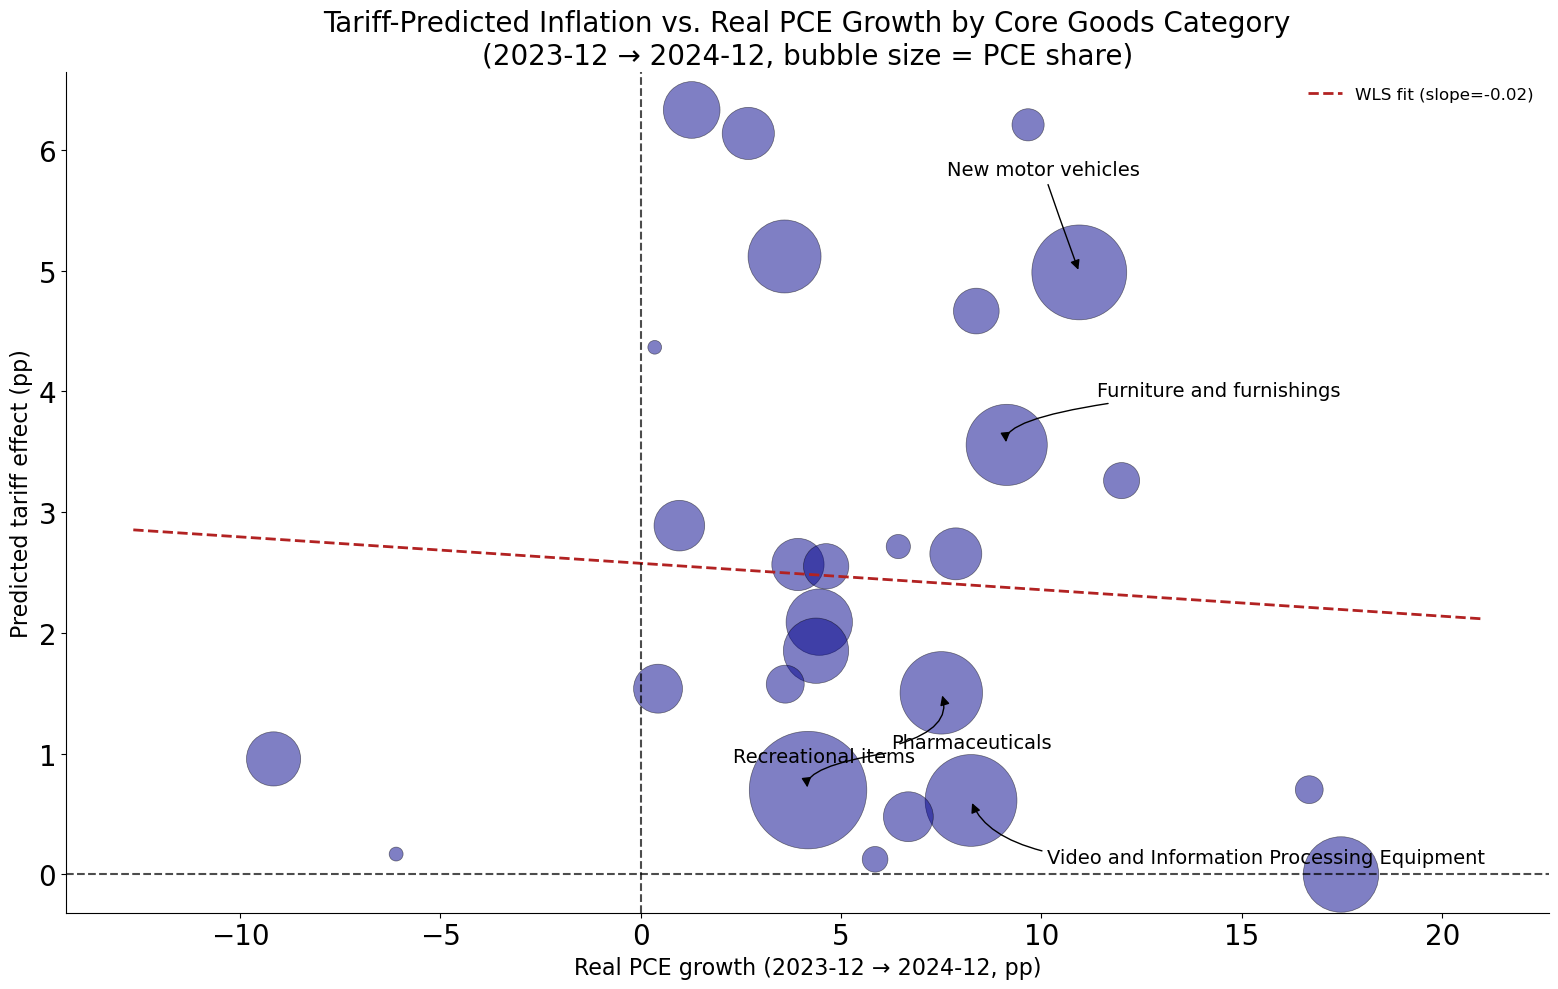

In [282]:

# ── Predicted tariff inflation vs. real PCE growth — scatter plot ─────────────
# Y-axis: predicted tariff effect per category (from Leontief / PCE bridge)
# X-axis: actual real PCE growth over config.REAL_PCE_GROWTH_START_MONTH →
#         config.REAL_PCE_GROWTH_END_MONTH  (same window as the previous plot)
#
# Reuses _rpce_plot from the cell above — no additional download needed.

x_pt = _rpce_plot["real_pce_growth"].values  * 100
y_pt = _rpce_plot["predicted_effect"].values * 100
w_pt = _rpce_plot["pce_share"].values

wls_pt = sm.WLS(y_pt, sm.add_constant(x_pt), weights=w_pt).fit()
intercept_pt, slope_pt = wls_pt.params
print(wls_pt.summary())

fig_pt, ax_pt = plt.subplots(figsize=(16, 10))

ax_pt.scatter(
    _rpce_plot["real_pce_growth"]   * 100,
    _rpce_plot["predicted_effect"]  * 100,
    s=_rpce_plot["pce_share"] * 50000,
    alpha=0.5, color="darkblue", edgecolors="black", linewidths=0.5,
)

x_fit_pt = np.linspace(x_pt.min() - 3.5, x_pt.max() + 3.5, 100)
ax_pt.plot(x_fit_pt, slope_pt * x_fit_pt + intercept_pt,
           color='firebrick', linewidth=2, linestyle='--',
           label=f'WLS fit (slope={slope_pt:.2f})')

ax_pt.axhline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)
ax_pt.axvline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)

_rpce_window_pt = f"{config.REAL_PCE_GROWTH_START_MONTH} → {config.REAL_PCE_GROWTH_END_MONTH}"
ax_pt.set_title(
    f"Tariff-Predicted Inflation vs. Real PCE Growth by Core Goods Category\n"
    f"({_rpce_window_pt}, bubble size = PCE share)",
    fontsize=20,
)
ax_pt.set_xlabel(f"Real PCE growth ({_rpce_window_pt}, pp)", fontsize=16)
ax_pt.set_ylabel("Predicted tariff effect (pp)", fontsize=16)
ax_pt.legend(fontsize=12, frameon=False, loc='upper right')
ax_pt.tick_params(axis="x", labelsize=20)
ax_pt.tick_params(axis="y", labelsize=20)
ax_pt.spines["right"].set_visible(False)
ax_pt.spines["top"].set_visible(False)

# ── Short-label helper ────────────────────────────────────────────────────────
def _short_label_pt(cat):
    if "harmaceutical" in cat:
        return "Pharmaceuticals"
    if "ideo" in cat:
        return "Video and Information Processing Equipment"
    return cat

# ── Annotate top 5 by PCE share ───────────────────────────────────────────────
_top5_pt = _rpce_plot.nlargest(5, "pce_share").reset_index(drop=True)
_offsets_pt = [(60, 30), (-95, 70), (55, -45), (-150, -50), (65, 35)]

for _rank, (_ox, _oy) in enumerate(_offsets_pt):
    _row_pt = _top5_pt.loc[_rank]
    ax_pt.annotate(
        _short_label_pt(_row_pt["PCE_category"]),
        xy=(_row_pt["real_pce_growth"] * 100, _row_pt["predicted_effect"] * 100),
        xycoords="data",
        xytext=(_ox, _oy),
        textcoords="offset points",
        horizontalalignment="left",
        arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
        fontsize=14,
    )

plt.tight_layout()
plt.savefig("../figures/predicted_tariff_vs_real_pce_growth.png", bbox_inches="tight", dpi=150)
plt.show()


                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.185
Model:                            WLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     5.674
Date:                Fri, 13 Mar 2026   Prob (F-statistic):             0.0251
Time:                        13:02:13   Log-Likelihood:                -76.194
No. Observations:                  27   AIC:                             156.4
Df Residuals:                      25   BIC:                             159.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2319      1.066     -2.094      0.0

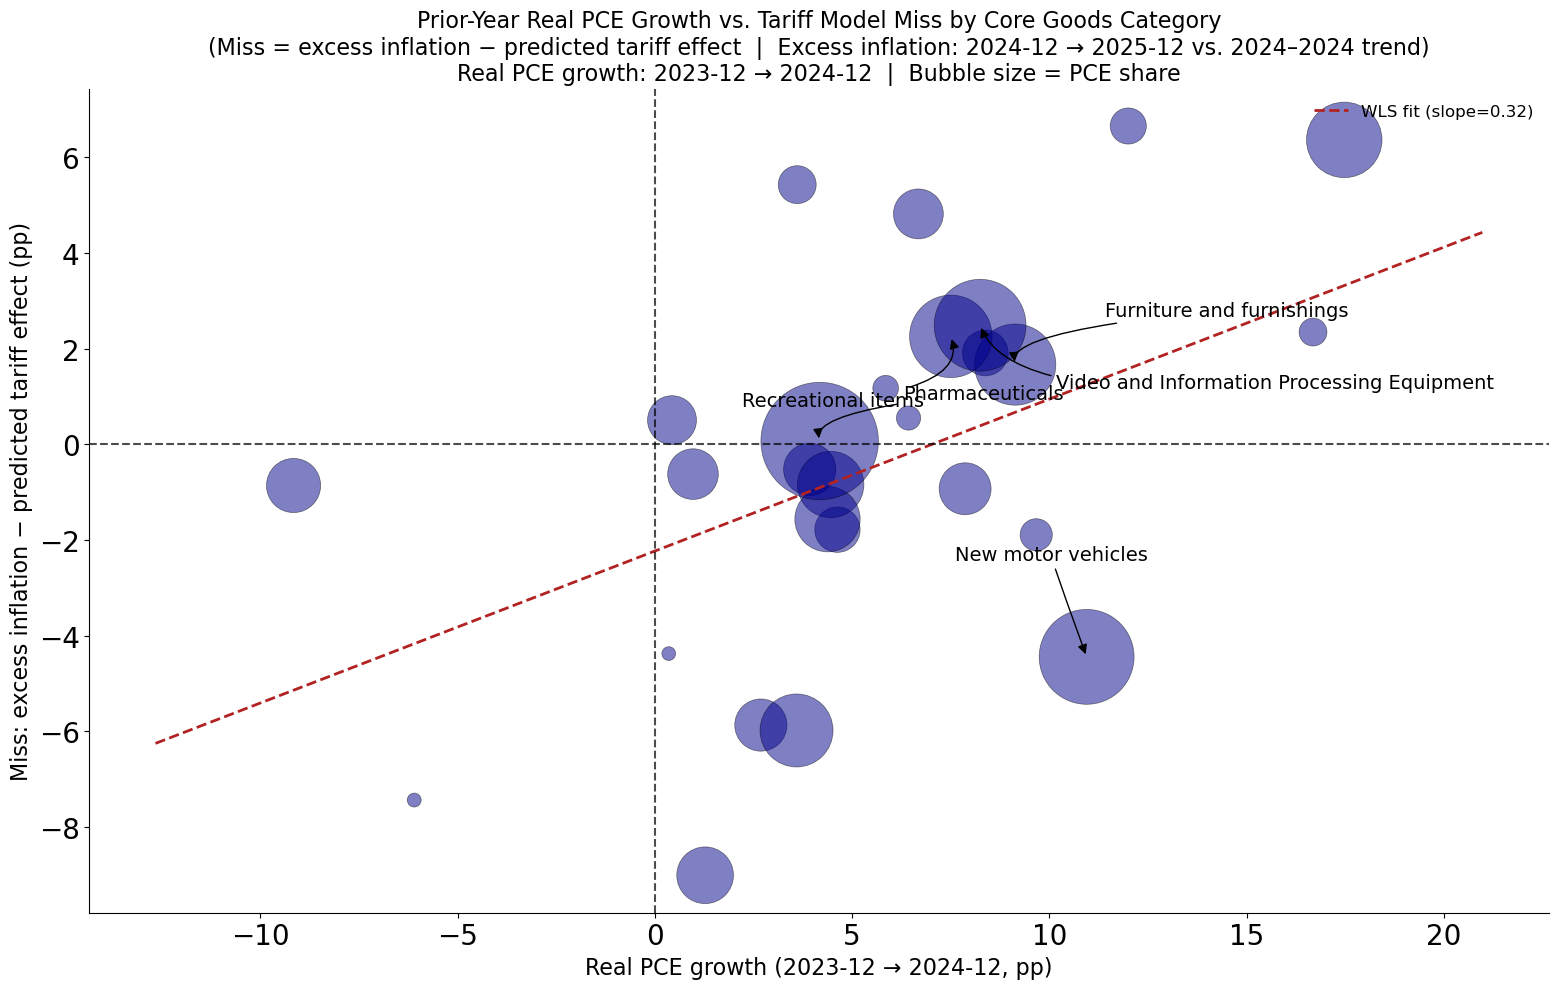

                                                              PCE_category  real_pce_growth_pp  predicted_pp  excess_inflation_pp  miss_pp  pce_share_pct
                                 Pharmaceutical and other medical products                 4.2           0.7                  0.8      0.1           14.3
                                                        New motor vehicles                10.9           5.0                  0.5     -4.4            9.3
Video, audio, photographic, and information processing equipment and media                 8.2           0.6                  3.1      2.5            8.7
                                                        Recreational items                 7.5           1.5                  3.8      2.3            7.1
                                                 Furniture and furnishings                 9.1           3.6                  5.2      1.7            6.8
                                      Net purchases of used motor vehicles  

In [283]:

# ── Real PCE growth (last year) vs. model miss — scatter plot ─────────────────
# Y-axis: miss = excess inflation − predicted tariff effect
#         Positive → actual inflation exceeded what tariffs alone predict
#         Negative → model over-predicted relative to what we see
# X-axis: real PCE growth last year (config.REAL_PCE_GROWTH_START_MONTH →
#         config.REAL_PCE_GROWTH_END_MONTH)
#
# Hypothesis: categories with strong prior-year demand surge show larger
# positive misses — i.e., demand dynamics explain why the tariff model
# under-predicts realized inflation in those categories.
#
# Reuses _rpce_plot from cell 18 — no additional download needed.

_miss_plot = _rpce_plot.copy()
_miss_plot["miss"] = _miss_plot["excess_inflation"] - _miss_plot["predicted_effect"]
_miss_plot = _miss_plot.dropna(subset=["real_pce_growth", "miss", "pce_share"])

# ── WLS fit ───────────────────────────────────────────────────────────────────
_x_miss = _miss_plot["real_pce_growth"].values * 100
_y_miss = _miss_plot["miss"].values            * 100
_w_miss = _miss_plot["pce_share"].values

wls_miss = sm.WLS(_y_miss, sm.add_constant(_x_miss), weights=_w_miss).fit()
_intercept_miss, _slope_miss = wls_miss.params
print(wls_miss.summary())

# ── Plot ──────────────────────────────────────────────────────────────────────
fig_miss, ax_miss = plt.subplots(figsize=(16, 10))

ax_miss.scatter(
    _miss_plot["real_pce_growth"] * 100,
    _miss_plot["miss"]            * 100,
    s=_miss_plot["pce_share"] * 50000,
    alpha=0.5, color="darkblue", edgecolors="black", linewidths=0.5,
)

_x_fit_miss = np.linspace(_x_miss.min() - 3.5, _x_miss.max() + 3.5, 100)
ax_miss.plot(_x_fit_miss, _slope_miss * _x_fit_miss + _intercept_miss,
             color="firebrick", linewidth=2, linestyle="--",
             label=f"WLS fit (slope={_slope_miss:.2f})")

ax_miss.axhline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)
ax_miss.axvline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)

_rpce_window_miss   = f"{config.REAL_PCE_GROWTH_START_MONTH} → {config.REAL_PCE_GROWTH_END_MONTH}"
_excess_window_miss = f"{config.EXCESS_CURRENT_START_MONTH} → {config.EXCESS_CURRENT_END_MONTH}"
_baseline_miss      = f"{config.EXCESS_BASELINE_START}–{config.EXCESS_BASELINE_END}"
ax_miss.set_title(
    f"Prior-Year Real PCE Growth vs. Tariff Model Miss by Core Goods Category\n"
    f"(Miss = excess inflation − predicted tariff effect  |  "
    f"Excess inflation: {_excess_window_miss} vs. {_baseline_miss} trend)\n"
    f"Real PCE growth: {_rpce_window_miss}  |  Bubble size = PCE share",
    fontsize=16,
)
ax_miss.set_xlabel(f"Real PCE growth ({_rpce_window_miss}, pp)", fontsize=16)
ax_miss.set_ylabel("Miss: excess inflation − predicted tariff effect (pp)", fontsize=16)
ax_miss.legend(fontsize=12, frameon=False, loc="upper right")
ax_miss.tick_params(axis="x", labelsize=20)
ax_miss.tick_params(axis="y", labelsize=20)
ax_miss.spines["right"].set_visible(False)
ax_miss.spines["top"].set_visible(False)

# ── Short-label helper ────────────────────────────────────────────────────────
def _short_label_miss(cat):
    if "harmaceutical" in cat:
        return "Pharmaceuticals"
    if "ideo" in cat:
        return "Video and Information Processing Equipment"
    return cat

# ── Annotate top 5 by PCE share ───────────────────────────────────────────────
_top5_miss    = _miss_plot.nlargest(5, "pce_share").reset_index(drop=True)
_offsets_miss = [(60, 30), (-95, 70), (55, -45), (-150, -50), (65, 35)]

for _rank, (_ox, _oy) in enumerate(_offsets_miss):
    _row_miss = _top5_miss.loc[_rank]
    ax_miss.annotate(
        _short_label_miss(_row_miss["PCE_category"]),
        xy=(_row_miss["real_pce_growth"] * 100, _row_miss["miss"] * 100),
        xycoords="data",
        xytext=(_ox, _oy),
        textcoords="offset points",
        horizontalalignment="left",
        arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
        fontsize=14,
    )

plt.tight_layout()
plt.savefig("../figures/real_pce_growth_vs_tariff_miss.png", bbox_inches="tight", dpi=150)
plt.show()

# ── Print data table ──────────────────────────────────────────────────────────
print(
    _miss_plot[["PCE_category", "real_pce_growth", "predicted_effect", "excess_inflation", "miss", "pce_share"]]
    .assign(
        real_pce_growth_pp  = lambda d: d["real_pce_growth"]  * 100,
        predicted_pp        = lambda d: d["predicted_effect"] * 100,
        excess_inflation_pp = lambda d: d["excess_inflation"] * 100,
        miss_pp             = lambda d: d["miss"]             * 100,
        pce_share_pct       = lambda d: d["pce_share"]        * 100,
    )
    [["PCE_category", "real_pce_growth_pp", "predicted_pp", "excess_inflation_pp", "miss_pp", "pce_share_pct"]]
    .sort_values("pce_share_pct", ascending=False)
    .to_string(index=False)
)
